# Satellite Collision Risk Assessment and Prediction (SCRAP)
**CSAI 801 — Machine Learning | Queen's University, Winter 2026**  
Mahmoud Alyosify (20595453) · Mohamed Yahya (20596298) · Mirna Embaby (20596311)

---

## Pipeline Overview

This notebook implements a two-stage supervised machine learning framework for predicting
the final collision risk between a satellite and space debris in Low Earth Orbit (LEO) using Conjunction Data Message (CDM).

**Operational Constraint:** All predictions use only telemetry data available at least
two days prior to the Time of Closest Approach (TCA).

### Architecture

```
RAW CDMs (time-series per event)
        |
        v
[1] 2-Day Cutoff Filtration  -- drop CDMs inside TCA-2day window
        |
        v
[2] Physics Feature Engineering  -- Mahalanobis distance, covariance, orbital geometry
        |
        v
[3] Time-Series Flattening  -- 11 aggregation statistics per feature
        |
        v
[4] Stage 1: Sentinel  (LightGBM Classifier)
        |    Maximises F2 (recall-weighted) to minimise false negatives
        |
        +-- Predicted LOW RISK  --> clip to -6.001 (safe)
        |
        +-- Predicted HIGH RISK --> Stage 2
                                        |
                                        v
                                [5] Stage 2: Specialist  (XGBoost Regressor)
                                        Fine-grained risk magnitude prediction
                                        trained on high-risk events only
```

**Evaluation Metric (ESA Official):**
$$L = \frac{1}{F_2} \times \text{MSE}_{HR}$$
where $F_2$ uses $\beta = 2$ (recall weighted 4x over precision) and MSE is computed
in probability space over high-risk events only.


## Section 1 — Environment Setup

In [113]:
# Install required packages
%pip install --break-system-packages -q xgboost lightgbm catboost optuna shap numpy pandas scikit-learn scipy matplotlib seaborn datasets jinja2 nbformat ipython

Note: you may need to restart the kernel to use updated packages.


## Section 2 — Imports and Global Constants

In [114]:
import numpy  as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import warnings
import os

warnings.filterwarnings('ignore')
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '3'

import xgboost  as xgb
import lightgbm as lgb
import optuna
import shap

optuna.logging.set_verbosity(optuna.logging.WARNING)

from datasets              import load_dataset
from scipy.optimize        import differential_evolution
from sklearn.model_selection import StratifiedGroupKFold, GroupKFold
from sklearn.metrics       import (precision_score, recall_score,
                                   fbeta_score, confusion_matrix)

np.random.seed(42)
pd.set_option('display.max_columns', None)

# Matplotlib style — clean academic output
plt.rcParams.update({
    'figure.dpi'       : 120,
    'axes.spines.top'  : False,
    'axes.spines.right': False,
    'axes.grid'        : True,
    'grid.alpha'       : 0.3,
    'font.size'        : 11,
})
PALETTE = {'hr': '#C0392B', 'lr': '#2980B9', 'neutral': '#2C3E50', 'accent': '#27AE60'}

# ── ESA Competition Constants ─────────────────────────────────────────────────
CUTOFF_DAYS    = 2.0          # operational 2-day forecast horizon
RISK_THRESHOLD = 1e-6         # ESA high-risk classification boundary
LOG_THRESHOLD  = -6.0         # log10(1e-6)
SIGMA_EPS      = 1e-10        # numerical stability floor
R_EARTH_KM     = 6378.137     # Earth's equatorial radius (km)
N_FOLDS        = 5            # StratifiedGroupKFold folds
BETA           = 2.0          # F_beta recall weight (ESA spec)
UNCERTAINTY_P  = 75           # percentile for high-uncertainty flag

# ── Hardware Detection ────────────────────────────────────────────────────────
def _detect_hardware():
    try:
        p = xgb.XGBRegressor(tree_method='hist', device='cuda', n_estimators=1)
        p.fit([[0]], [0])
        return 'cuda'
    except Exception:
        pass
    try:
        import torch
        if torch.backends.mps.is_available():
            return 'mps'
    except Exception:
        pass
    return 'cpu'

HW         = _detect_hardware()
XGB_DEVICE = 'cuda' if HW == 'cuda' else 'cpu'
LGB_DEVICE = 'gpu'  if HW == 'cuda' else 'cpu'
N_TRIALS   = 80 if HW == 'cuda' else 30

print(f'Hardware detected : {HW.upper()}')
print(f'XGBoost device    : {XGB_DEVICE}')
print(f'LightGBM device   : {LGB_DEVICE}')
print(f'Optuna trials     : {N_TRIALS}')
print(f'Risk threshold    : log10({RISK_THRESHOLD}) = {LOG_THRESHOLD}')


Hardware detected : CUDA
XGBoost device    : cuda
LightGBM device   : gpu
Optuna trials     : 80
Risk threshold    : log10(1e-06) = -6.0


## Section 3 — Official Competition Loss Function

The ESA Kelvins competition evaluates submissions using:

$$L(\hat{r}) = \frac{1}{F_2} \times \text{MSE}_{HR}$$

**Key implementation details:**
- $\text{MSE}_{HR}$ is computed in **probability space** (i.e., on $10^y$, not on $y$ directly)
- The high-risk threshold is $r \geq 10^{-6}$, equivalent to $\log_{10}(r) \geq -6$
- $F_2$ uses $\beta = 2$, weighting recall four times more heavily than precision
- A composite score $S = F_2 / (1 + \text{MSE}_{HR}) \in [0, 1]$ is used internally
  for threshold and hyperparameter selection, since $L$ is numerically unstable when $F_2 \approx 0$


In [115]:
def competition_loss(y_true_log10, y_pred_log10,
                     beta=BETA, threshold=LOG_THRESHOLD, verbose=True):
    """
    Official ESA competition loss: L = (1 / F2) * MSE_HR

    Parameters
    ----------
    y_true_log10 : array-like
        True risk values in log10 space.
    y_pred_log10 : array-like
        Predicted risk values in log10 space.
    beta : float
        F-beta parameter (default 2.0 per ESA spec).
    threshold : float
        Log10 classification boundary (default -6.0 = log10(1e-6)).
    verbose : bool
        Print detailed breakdown.

    Returns
    -------
    float : Loss L. Lower is better. Returns inf if F2 = 0 or no HR events.

    Notes
    -----
    MSE is computed in probability space (10^y), not log space.
    Predictions are clipped to [-50, 0] to prevent numerical overflow.
    """
    y_true = np.asarray(y_true_log10, dtype=float).ravel()
    y_pred = np.clip(np.asarray(y_pred_log10, dtype=float).ravel(), -50, 0)

    r_true = 10.0 ** y_true
    r_pred = 10.0 ** y_pred

    t_prob     = 10.0 ** threshold
    y_true_bin = (r_true >= t_prob).astype(int)
    y_pred_bin = (r_pred >= t_prob).astype(int)

    prec  = precision_score(y_true_bin, y_pred_bin, zero_division=0.0)
    rec   = recall_score   (y_true_bin, y_pred_bin, zero_division=0.0)
    denom = beta**2 * prec + rec
    f2    = 0.0 if denom == 0 else (1 + beta**2) * prec * rec / denom

    hr_mask = y_true_bin == 1
    n_hr    = int(hr_mask.sum())
    if n_hr == 0:
        if verbose:
            print('  Warning: No high-risk events in ground truth.')
        return float('inf')

    mse_hr = float(np.mean((r_true[hr_mask] - r_pred[hr_mask]) ** 2))
    loss   = float('inf') if f2 == 0.0 else (1.0 / f2) * mse_hr

    if verbose:
        tp = int(((y_true_bin == 1) & (y_pred_bin == 1)).sum())
        fp = int(((y_true_bin == 0) & (y_pred_bin == 1)).sum())
        fn = int(((y_true_bin == 1) & (y_pred_bin == 0)).sum())
        print(f'  Threshold        : log10(r) >= {threshold}  (r >= {10**threshold:.0e})')
        print(f'  High-risk events : {n_hr:>5} / {len(r_true)}')
        print(f'  TP={tp:>5}  FP={fp:>5}  FN={fn:>5}')
        print(f'  Precision        : {prec:.4f}')
        print(f'  Recall           : {rec:.4f}  [beta=2: recall weighted 4x over precision]')
        print(f'  F2 Score         : {f2:.4f}')
        print(f'  MSE_HR (prob)    : {mse_hr:.4e}  [probability space]')
        print(f'  Loss L           : {loss:.6f}  [lower is better]')
    return loss


def loss_components(y_true_log10, y_pred_log10,
                    beta=BETA, threshold=LOG_THRESHOLD):
    """
    Return (f2, mse_hr, L, S) without printing.
    S = F2 / (1 + MSE_HR) is the composite score used for
    threshold tuning and hyperparameter selection.
    """
    y_true = np.asarray(y_true_log10, dtype=float).ravel()
    y_pred = np.clip(np.asarray(y_pred_log10, dtype=float).ravel(), -50, 0)
    r_true = 10.0 ** y_true
    r_pred = 10.0 ** y_pred
    t_prob = 10.0 ** threshold
    y_true_bin = (r_true >= t_prob).astype(int)
    y_pred_bin = (r_pred >= t_prob).astype(int)
    prec  = precision_score(y_true_bin, y_pred_bin, zero_division=0.0)
    rec   = recall_score   (y_true_bin, y_pred_bin, zero_division=0.0)
    denom = beta**2 * prec + rec
    f2    = 0.0 if denom == 0 else (1 + beta**2) * prec * rec / denom
    hr_mask = y_true_bin == 1
    n_hr    = int(hr_mask.sum())
    if n_hr == 0:
        return 0.0, float('inf'), float('inf'), 0.0
    mse_hr = float(np.mean((r_true[hr_mask] - r_pred[hr_mask]) ** 2))
    L      = float('inf') if f2 == 0.0 else (1.0 / f2) * mse_hr
    S      = f2 / (1.0 + mse_hr)
    return f2, mse_hr, L, S


# Sanity check
_y = np.full(200, LOG_THRESHOLD - 1.0)
_y[:10] = LOG_THRESHOLD + 0.5
f2, mse, L, S = loss_components(_y, _y)
print(f'Sanity check (perfect prediction):')
print(f'  F2={f2:.4f}  MSE_HR={mse:.2e}  L={L:.6f}  S={S:.4f}')

Sanity check (perfect prediction):
  F2=1.0000  MSE_HR=0.00e+00  L=0.000000  S=1.0000


## Section 4 — Data Loading

Dataset: ESA Historical Conjunction Data Messages (CDMs)  
Source: HuggingFace — `mahmoudalyosify/SCRAP`


In [116]:
HF_DATASET_ID = 'mahmoudalyosify/SCRAP'

def load_split(split):
    """Load a train/test split from HuggingFace with Parquet fallback."""
    try:
        ds = load_dataset(HF_DATASET_ID, split=split)
        return ds.to_pandas()
    except Exception as e:
        print(f'  HuggingFace API failed: {e}')
        print('  Attempting Parquet fallback...')
        import urllib.request, io
        base = ('https://huggingface.co/datasets/'
                'mahmoudalyosify/SCRAP/resolve/main/data')
        buf = io.BytesIO()
        urllib.request.urlretrieve(
            f'{base}/{split}-00000-of-00001.parquet', buf)
        return pd.read_parquet(buf)

print('Loading training split...')
df_train_raw = load_split('train')
print(f'  Shape   : {df_train_raw.shape}')
print(f'  Events  : {df_train_raw["event_id"].nunique():,}')

print('Loading test split...')
df_test_raw = load_split('test')
print(f'  Shape   : {df_test_raw.shape}')
print(f'  Events  : {df_test_raw["event_id"].nunique():,}')



Loading training split...
  Shape   : (162634, 103)
  Events  : 13,154
Loading test split...
  Shape   : (24484, 103)
  Events  : 2,167


In [117]:
df_train_raw.head(20)

,event_id,time_to_tca,mission_id,risk,max_risk_estimate,max_risk_scaling,miss_distance,relative_speed,relative_position_r,relative_position_t,relative_position_n,relative_velocity_r,relative_velocity_t,relative_velocity_n,t_time_lastob_start,t_time_lastob_end,t_recommended_od_span,t_actual_od_span,t_obs_available,t_obs_used,t_residuals_accepted,t_weighted_rms,t_rcs_estimate,t_cd_area_over_mass,t_cr_area_over_mass,t_sedr,t_j2k_sma,t_j2k_ecc,t_j2k_inc,t_ct_r,t_cn_r,t_cn_t,t_crdot_r,t_crdot_t,t_crdot_n,t_ctdot_r,t_ctdot_t,t_ctdot_n,t_ctdot_rdot,t_cndot_r,t_cndot_t,t_cndot_n,t_cndot_rdot,t_cndot_tdot,c_object_type,c_time_lastob_start,c_time_lastob_end,c_recommended_od_span,c_actual_od_span,c_obs_available,c_obs_used,c_residuals_accepted,c_weighted_rms,c_rcs_estimate,c_cd_area_over_mass,c_cr_area_over_mass,c_sedr,c_j2k_sma,c_j2k_ecc,c_j2k_inc,c_ct_r,c_cn_r,c_cn_t,c_crdot_r,c_crdot_t,c_crdot_n,c_ctdot_r,c_ctdot_t,c_ctdot_n,c_ctdot_rdot,c_cndot_r,c_cndot_t,c_cndot_n,c_cndot_rdot,c_cndot_tdot,t_span,c_span,t_h_apo,t_h_per,c_h_apo,c_h_per,geocentric_latitude,azimuth,elevation,mahalanobis_distance,t_position_covariance_det,c_position_covariance_det,t_sigma_r,c_sigma_r,t_sigma_t,c_sigma_t,t_sigma_n,c_sigma_n,t_sigma_rdot,c_sigma_rdot,t_sigma_tdot,c_sigma_tdot,t_sigma_ndot,c_sigma_ndot,F10,F3M,SSN,AP
0,0,1.566798,5,-10.204955,-7.834756,8.602101,14923.0,13792.0,453.8,5976.6,-13666.8,-7.2,-12637.0,-5525.9,1.0,0.0,3.78,3.78,459,458,98.9,1.265,0.4020,0.013826,0.007173,0.000051,6996.918867,0.003997,97.806412,-0.397969,0.292258,0.040799,0.394221,-0.999674,-0.038498,-0.981098,0.214612,-0.316493,-0.210247,0.170737,-0.001551,0.531593,0.002117,-0.179278,UNKNOWN,180.0,2.0,15.85,15.85,15.0,15.0,100.0,2.360,NaN,0.348701,0.126607,0.001406,7006.607320,0.003144,74.045735,-0.824859,0.473976,-0.002576,0.825216,-0.999998,0.003565,-0.732954,0.220006,-0.814249,-0.220621,0.249855,0.196620,0.722186,-0.196908,-0.668487,1.0,2.0,646.745439,590.818294,650.497251,606.443389,-73.574095,-23.618769,0.029910,129.430951,7.373471e+05,4.429923e+16,4.057932,266.722309,137.617114,54366.864909,1.781418,46.612573,0.147350,58.272095,0.004092,0.165044,0.002987,0.386462,89.0,83.0,42.0,11.0
1,0,1.207494,5,-10.355758,-7.848937,8.956374,14544.0,13792.0,474.3,5821.2,-13319.8,-7.0,-12637.0,-5525.9,1.0,0.0,3.79,3.79,456,455,98.5,1.270,0.4020,0.013487,0.009139,0.000060,6996.920255,0.003996,97.806420,-0.073137,0.297366,0.060541,0.069652,-0.998192,-0.052511,-0.994240,-0.029644,-0.302333,0.034030,0.179696,0.001552,0.561142,-0.005165,-0.181036,UNKNOWN,180.0,2.0,15.85,15.85,15.0,15.0,100.0,2.360,NaN,0.348701,0.126607,0.001406,7006.621053,0.003144,74.045736,-0.818207,0.482754,-0.003578,0.818573,-0.999998,0.004574,-0.728759,0.202595,-0.817490,-0.203216,0.258964,0.195718,0.721903,-0.196008,-0.674979,1.0,2.0,646.743506,590.823004,650.513314,606.454793,-73.570690,-23.618769,0.029079,271.540424,1.141390e+05,4.378610e+16,3.526780,262.191819,56.070117,54082.067268,1.800959,46.595869,0.059672,57.966413,0.003753,0.164383,0.002933,0.386393,89.0,83.0,42.0,11.0
2,0,0.952193,5,-10.345631,-7.847406,8.932195,14475.0,13792.0,474.6,5796.2,-13256.1,-7.0,-12637.0,-5525.9,1.0,0.0,3.79,3.80,456,455,98.5,1.257,0.4020,0.013357,0.007057,0.000060,6996.920553,0.003996,97.806418,-0.109230,0.305189,0.043711,0.107079,-0.996235,-0.034287,-0.996674,0.033933,-0.308501,-0.030161,0.123760,0.019630,0.579274,-0.023726,-0.125737,UNKNOWN,180.0,2.0,15.85,15.85,15.0,15.0,100.0,2.360,NaN,0.348701,0.126607,0.001406,7006.623524,0.003144,74.045737,-0.817408,0.483828,-0.003742,0.817774,-0.999998,0.004738,-0.729083,0.201698,-0.817662,-0.202320,0.260092,0.195558,0.721854,-0.195849,-0.675347,1.0,2.0,646.745607,590.821499,650.515082,606.457965,-73.570088,-23.618769,0.029079,347.899292,4.696004e+04,4.369105e+16,3.362037,261.666544,37.497947,54027.391201,1.821940,46.592757,0.039258,57.907599,0.003576,0.164352,0.002967,0.386381,89.0,83.0,42.0,11.0
3,0,0.579669,5,-10.337809,-7.845880,8.913444,14579.0,13792.0,472.7,5838.9,-13350.7,-7.0,-12637.0,

In [118]:
df_test_raw.head(20)

,event_id,time_to_tca,mission_id,risk,max_risk_estimate,max_risk_scaling,miss_distance,relative_speed,relative_position_r,relative_position_t,relative_position_n,relative_velocity_r,relative_velocity_t,relative_velocity_n,t_time_lastob_start,t_time_lastob_end,t_recommended_od_span,t_actual_od_span,t_obs_available,t_obs_used,t_residuals_accepted,t_weighted_rms,t_rcs_estimate,t_cd_area_over_mass,t_cr_area_over_mass,t_sedr,t_j2k_sma,t_j2k_ecc,t_j2k_inc,t_ct_r,t_cn_r,t_cn_t,t_crdot_r,t_crdot_t,t_crdot_n,t_ctdot_r,t_ctdot_t,t_ctdot_n,t_ctdot_rdot,t_cndot_r,t_cndot_t,t_cndot_n,t_cndot_rdot,t_cndot_tdot,c_object_type,c_time_lastob_start,c_time_lastob_end,c_recommended_od_span,c_actual_od_span,c_obs_available,c_obs_used,c_residuals_accepted,c_weighted_rms,c_rcs_estimate,c_cd_area_over_mass,c_cr_area_over_mass,c_sedr,c_j2k_sma,c_j2k_ecc,c_j2k_inc,c_ct_r,c_cn_r,c_cn_t,c_crdot_r,c_crdot_t,c_crdot_n,c_ctdot_r,c_ctdot_t,c_ctdot_n,c_ctdot_rdot,c_cndot_r,c_cndot_t,c_cndot_n,c_cndot_rdot,c_cndot_tdot,t_span,c_span,t_h_apo,t_h_per,c_h_apo,c_h_per,geocentric_latitude,azimuth,elevation,mahalanobis_distance,t_position_covariance_det,c_position_covariance_det,t_sigma_r,c_sigma_r,t_sigma_t,c_sigma_t,t_sigma_n,c_sigma_n,t_sigma_rdot,c_sigma_rdot,t_sigma_tdot,c_sigma_tdot,t_sigma_ndot,c_sigma_ndot,F10,F3M,SSN,AP
0,0,6.842095,19,-7.296967,-7.208941,1.787894,31816.0,7929.0,-365.5,26967.0,16880.6,-26.3,-4207.7,6720.9,1.0,0.0,7.50,7.49,215,214,99.4,1.293,0.4344,0.015128,0.016234,0.000018,7084.698187,0.003744,98.217983,-0.270354,-0.657060,0.196264,0.210330,-0.997253,-0.142771,-0.998425,0.216358,0.656637,-0.155433,0.456629,-0.108973,-0.086419,0.081347,-0.456798,UNKNOWN,180.0,2.0,29.45,29.44,18.0,17.0,83.3,4.113,NaN,0.308274,0.106612,0.000379,7082.280567,0.004097,74.114497,-0.012443,-0.589099,0.063823,0.017109,-0.999983,-0.064830,-0.999539,-0.015848,0.588556,0.011187,0.182553,-0.142693,-0.506554,0.142522,-0.178864,1.50,2.0,733.085558,680.036816,733.157975,675.129158,-66.171283,57.950882,0.190036,52.081328,7.748198e+07,4.812243e+16,7.414544,212.775210,359.072138,28182.398762,4.557019,45.386672,0.371943,29.669476,0.007763,0.223996,0.011833,1.375099,76.0,74.0,29.0,11.0
1,0,6.571818,19,-7.282496,-7.199833,1.759386,31095.0,7929.0,-361.8,26356.6,16497.2,-25.6,-4207.7,6720.9,1.0,0.0,7.50,7.49,215,214,99.4,1.293,0.4344,0.015128,0.016234,0.000018,7084.697461,0.003744,98.217984,-0.273973,-0.656964,0.199647,0.212957,-0.997155,-0.145260,-0.998472,0.220856,0.656541,-0.158922,0.456633,-0.110415,-0.086295,0.082320,-0.456824,UNKNOWN,180.0,2.0,29.45,29.44,18.0,17.0,83.3,4.113,NaN,0.308274,0.106612,0.000379,7082.282379,0.004097,74.114498,-0.011881,-0.588955,0.064956,0.016580,-0.999983,-0.065971,-0.999553,-0.015964,0.588383,0.011270,0.182546,-0.143287,-0.507868,0.143116,-0.178881,1.50,2.0,733.085727,680.035195,733.159131,675.131626,-66.174477,57.950882,0.184979,51.832431,7.452485e+07,4.752620e+16,7.413035,212.758643,352.579069,27984.451040,4.556956,45.426864,0.364986,29.460828,0.007762,0.223983,0.011833,1.375117,75.0,74.0,24.0,9.0
2,0,6.112986,19,-7.316053,-7.217886,1.824263,32202.0,7929.0,-370.7,27294.4,17085.1,-26.6,-4207.7,6720.9,1.0,0.0,7.79,7.79,209,208,99.5,1.298,0.4344,0.014540,0.020434,0.000017,7084.698697,0.003744,98.218012,-0.361151,-0.560374,0.235602,0.295058,-0.996456,-0.183190,-0.998904,0.317612,0.559722,-0.250362,0.422270,-0.110323,0.025867,0.085265,-0.423264,UNKNOWN,180.0,2.0,29.45,29.44,18.0,17.0,83.3,4.113,NaN,0.308274,0.106612,0.000379,7082.279019,0.004097,74.114497,-0.013286,-0.589183,0.063440,0.017940,-0.999983,-0.064445,-0.999520,-0.015601,0.588660,0.010952,0.182607,-0.142473,-0.505868,0.142302,-0.178876,1.50,2.0,733.086160,680.037234,733.156904,675.127135,-66.169549,57.950882,0.192204,63.876219,5.821566e+07,4.833258e+16,7.834560,212.784398,295.356632,28256.047140,4.273193,45.365681,0.303518,29.747208,0.008190,0.223999,0.010530,1.375092,75.0,74.0,24.0,9.0
3,0,5.921955,19,-7.334138,-7.228707,1.865396,32878.0,7929.0,-376.3,27867.5,17443.8,-27.2,-4207.7,6720

## Scrap data visualizations 


In [119]:
# ── Visualization imports (add any missing ones) ─────────────────────────────
import plotly.graph_objects as go
import plotly.express as px
from plotly.subplots import make_subplots
import matplotlib.colors as mcolors
# Aliases expected by viz cells
df_train_raw_viz = df_train_raw.copy()
df_test_raw_viz  = df_test_raw.copy()
df_all           = pd.concat([df_train_raw, df_test_raw], ignore_index=True)
print(f'Viz data ready: {len(df_all):,} total CDM records | {df_all["event_id"].nunique():,} events')


Viz data ready: 187,118 total CDM records | 13,154 events


## Data Preparation & Feature Engineering

In [120]:
# 2-day operational cutoff (SCRAP's core constraint)
TCA_CUTOFF   = 2.0
RISK_THRESH  = -6.0    # log10(10^-6)

# CDMs BEFORE the 2-day cutoff (what model never sees)
df_before = df_all[df_all['time_to_tca'] >= TCA_CUTOFF].copy()
df_after  = df_all[df_all['time_to_tca'] <  TCA_CUTOFF].copy()

# Risk classification
df_all['risk_category'] = pd.cut(
    df_all['risk'],
    bins=[-np.inf, -8, -6, -4, -2, np.inf],
    labels=['Negligible\n(<10⁻⁸)', 'Safe\n(10⁻⁸–10⁻⁶)',
            'Watch\n(10⁻⁶–10⁻⁴)', 'Danger\n(10⁻⁴–10⁻²)', 'Critical\n(>10⁻²)']
)

df_all['is_high_risk'] = df_all['risk'] >= RISK_THRESH

# Per-event final risk (last CDM per event, after TCA)
df_final = (df_all
    .sort_values('time_to_tca')
    .groupby('event_id', as_index=False)
    .first()
)
df_final['is_high_risk'] = df_final['risk'] >= RISK_THRESH

# Mahalanobis-inspired separation (miss_distance normalised by covariance diagonal)
df_all['sigma_r'] = np.sqrt(np.abs(df_all.get('t_cr_r', pd.Series(np.ones(len(df_all))))))
df_all['mahal_proxy'] = df_all['miss_distance'] / (df_all['sigma_r'].clip(lower=1e-3) + 1e-6)

print(f"   Feature engineering complete")
print(f"   CDMs ≥ 2-day boundary : {len(df_before):,}")
print(f"   Events total          : {df_final['event_id'].nunique():,}")
print(f"   High-risk events      : {df_final['is_high_risk'].sum():,}  "
      f"({df_final['is_high_risk'].mean()*100:.2f}%)")
print(f"   Risk range            : {df_all['risk'].min():.2f} → {df_all['risk'].max():.2f} log₁₀")

   Feature engineering complete
   CDMs ≥ 2-day boundary : 136,423
   Events total          : 13,154
   High-risk events      : 373  (2.84%)
   Risk range            : -30.00 → -1.44 log₁₀


## Class Imbalance — The Core Challenge

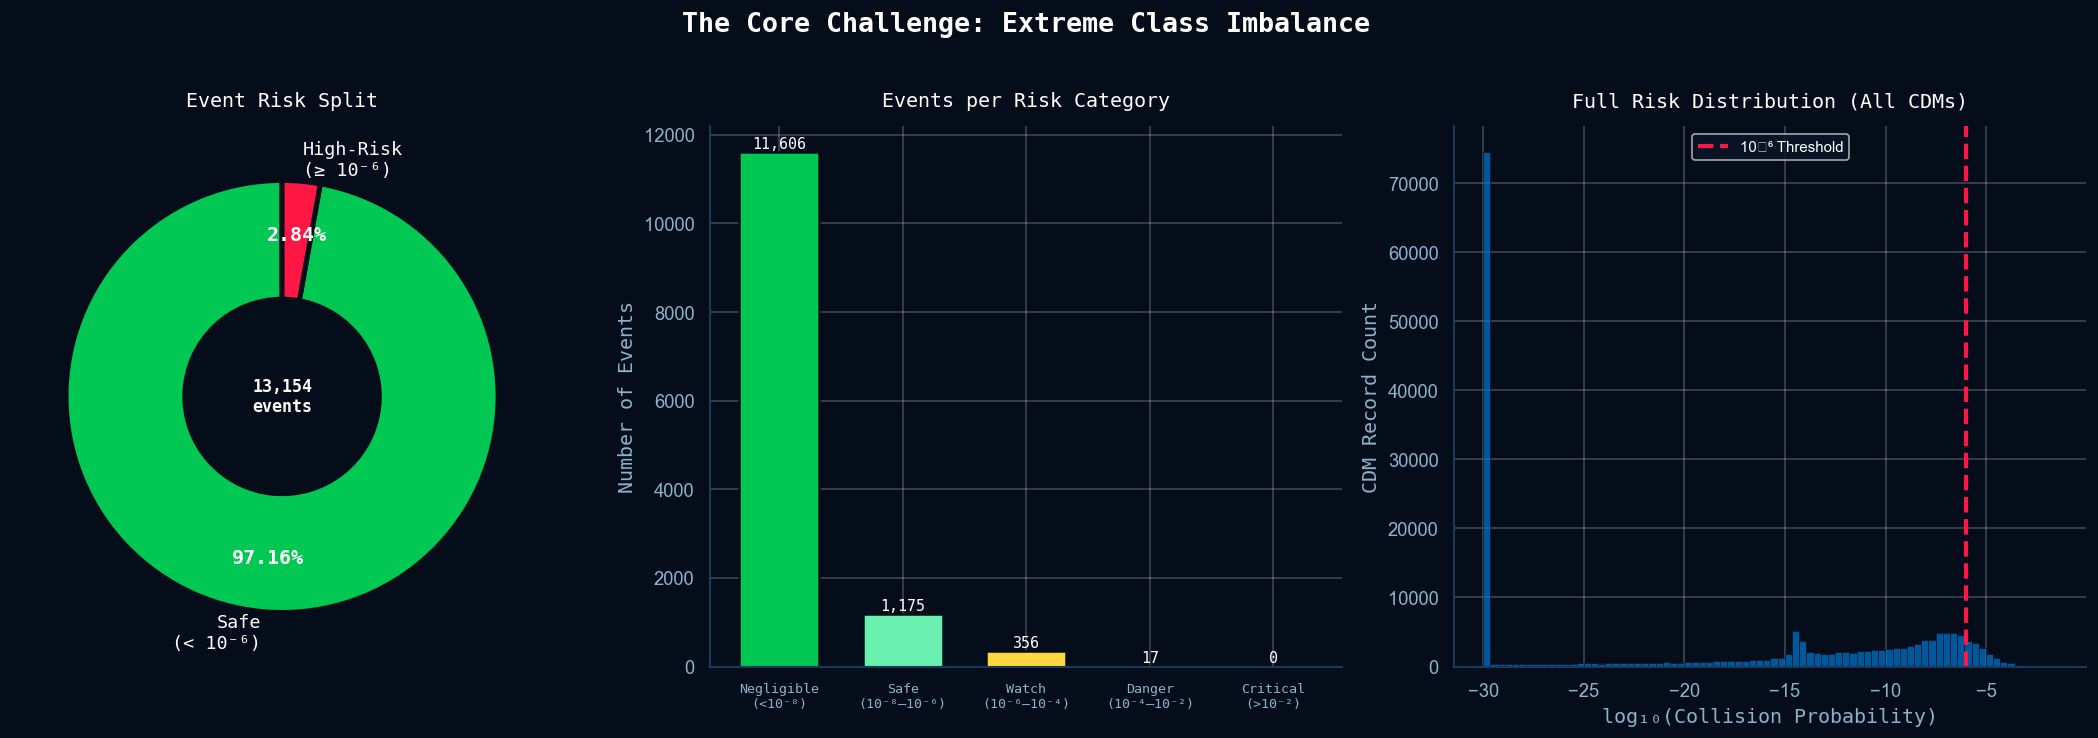

Figure 1: Class imbalance


In [121]:
fig, axes = plt.subplots(1, 3, figsize=(18, 6), facecolor='#050d1a')
plt.suptitle('The Core Challenge: Extreme Class Imbalance',
             fontsize=16, fontweight='bold', color='white',
             fontfamily='monospace', y=1.02)

cat_counts = df_final['risk_category'].value_counts().sort_index()
colors_cat = ['#00c853','#69f0ae','#ffd740','#ff6d00','#ff1744']

# ── 3a: Donut chart ──────────────────────────────────────────────────────────
ax = axes[0]; ax.set_facecolor('#050d1a')
safe_n     = (df_final['risk'] < RISK_THRESH).sum()
highrisk_n = (df_final['risk'] >= RISK_THRESH).sum()
wedge_data = [safe_n, highrisk_n]
wedge_cols = ['#00c853','#ff1744']
wedges, texts, autotexts = ax.pie(
    wedge_data, labels=['Safe\n(< 10⁻⁶)', 'High-Risk\n(≥ 10⁻⁶)'],
    colors=wedge_cols, autopct='%1.2f%%', startangle=90,
    pctdistance=0.75, wedgeprops=dict(width=0.55, edgecolor='#050d1a', linewidth=3),
    textprops=dict(color='white', fontfamily='monospace', fontsize=11),
)
for at in autotexts: at.set_fontsize(12); at.set_fontweight('bold')
ax.set_title('Event Risk Split', color='white', fontfamily='monospace', pad=12)
# Centre annotation
ax.text(0, 0, f'{df_final["event_id"].nunique():,}\nevents',
        ha='center', va='center', color='white',
        fontsize=10, fontfamily='monospace', fontweight='bold')

# ── 3b: Risk category bar ────────────────────────────────────────────────────
ax = axes[1]; ax.set_facecolor('#050d1a')
bars = ax.bar(range(len(cat_counts)), cat_counts.values,
              color=colors_cat[:len(cat_counts)], edgecolor='#050d1a', linewidth=1.5,
              width=0.65)
for bar, val in zip(bars, cat_counts.values):
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+15,
            f'{val:,}', ha='center', va='bottom',
            color='white', fontsize=9, fontfamily='monospace')
ax.set_xticks(range(len(cat_counts)))
ax.set_xticklabels(cat_counts.index, color='#8ab4cc', fontsize=8, fontfamily='monospace')
ax.set_title('Events per Risk Category', color='white', fontfamily='monospace', pad=12)
ax.set_ylabel('Number of Events', color='#8ab4cc', fontfamily='monospace')
ax.tick_params(colors='#8ab4cc')
for spine in ax.spines.values(): spine.set_edgecolor('#1a3a5c')
ax.set_facecolor('#050d1a')
ax.yaxis.label.set_color('#8ab4cc')

# ── 3c: Log-scale risk distribution of all CDM records ───────────────────────
ax = axes[2]; ax.set_facecolor('#050d1a')
ax.hist(df_all['risk'].dropna(), bins=80, color='#0078d4', alpha=0.7,
        edgecolor='#050d1a', linewidth=0.5)
ax.axvline(RISK_THRESH, color='#ff1744', linestyle='--', linewidth=2.5,
           label=f'10⁻⁶ Threshold')
ax.set_xlabel('log₁₀(Collision Probability)', color='#8ab4cc', fontfamily='monospace')
ax.set_ylabel('CDM Record Count', color='#8ab4cc', fontfamily='monospace')
ax.set_title('Full Risk Distribution (All CDMs)', color='white', fontfamily='monospace', pad=12)
ax.tick_params(colors='#8ab4cc')
ax.legend(facecolor='#0a1628', labelcolor='white', fontsize=9)
for spine in ax.spines.values(): spine.set_edgecolor('#1a3a5c')

plt.tight_layout()
plt.savefig('viz_01_imbalance.png', dpi=150, bbox_inches='tight',
            facecolor='#050d1a', edgecolor='none')
plt.show()
print("Figure 1: Class imbalance")

## Risk Evolution Over Time (CDM Time Series)

In [122]:
# Shows how risk evolves as TCA approaches — the 48-hr boundary is critical.

# Sample events: a few safe, a few high-risk (for clean display)
rng = np.random.default_rng(99)

hr_events  = df_final[df_final['is_high_risk']]['event_id'].values
safe_events = df_final[~df_final['is_high_risk']]['event_id'].values

sample_hr   = rng.choice(hr_events,   size=min(8, len(hr_events)),   replace=False)
sample_safe = rng.choice(safe_events, size=min(6, len(safe_events)), replace=False)

fig = go.Figure()

# High-risk trajectories
for eid in sample_hr:
    sub = df_all[df_all['event_id']==eid].sort_values('time_to_tca', ascending=False)
    fig.add_trace(go.Scatter(
        x=sub['time_to_tca'], y=sub['risk'],
        mode='lines+markers',
        line=dict(color='rgba(255,23,68,0.75)', width=2),
        marker=dict(size=5, color='#ff1744'),
        name=f'High-Risk {eid}',
        legendgroup='highrisk',
        showlegend=True if eid == sample_hr[0] else False,
        legendgrouptitle_text='High-Risk Events' if eid == sample_hr[0] else None,
        hovertemplate=(
            f'<b>Event {eid}</b><br>'
            'TCA: %{x:.2f} days<br>'
            'log₁₀(P): %{y:.3f}<extra></extra>'
        )
    ))

# Safe trajectories
for eid in sample_safe:
    sub = df_all[df_all['event_id']==eid].sort_values('time_to_tca', ascending=False)
    fig.add_trace(go.Scatter(
        x=sub['time_to_tca'], y=sub['risk'],
        mode='lines+markers',
        line=dict(color='rgba(0,200,83,0.5)', width=1.5),
        marker=dict(size=4, color='#00c853'),
        name=f'Safe {eid}',
        legendgroup='safe',
        showlegend=True if eid == sample_safe[0] else False,
        legendgrouptitle_text='Safe Events' if eid == sample_safe[0] else None,
        hovertemplate=(
            f'<b>Event {eid}</b><br>'
            'TCA: %{x:.2f} days<br>'
            'log₁₀(P): %{y:.3f}<extra></extra>'
        )
    ))

# 48-hr boundary line
fig.add_vline(x=TCA_CUTOFF, line_dash='dash', line_color='#00d4ff', line_width=2.5,
              annotation_text='48-hr Operational Cutoff<br>(SCRAP prediction boundary)',
              annotation_font_color='#00d4ff', annotation_font_size=11)

# 10^-6 threshold line
fig.add_hline(y=RISK_THRESH, line_dash='dot', line_color='#ff6d00', line_width=2,
              annotation_text='10⁻⁶ High-Risk Threshold',
              annotation_font_color='#ff6d00', annotation_font_size=11)

fig.update_layout(
    title=dict(text='<b>Risk Evolution Over Time — CDM Time Series</b><br>'
               '<sup>Each line = one conjunction event · Predictions made at x=2.0 days using only past data</sup>',
               font=dict(color='white', family='monospace', size=15)),
    xaxis=dict(title='Days to TCA (Time of Closest Approach)',
               color='#8ab4cc', gridcolor='#0d2040',
               autorange='reversed'),
    yaxis=dict(title='log₁₀(Collision Probability)',
               color='#8ab4cc', gridcolor='#0d2040'),
    paper_bgcolor='#050d1a', plot_bgcolor='#050d1a',
    font=dict(color='#8ab4cc', family='monospace'),
    legend=dict(bgcolor='rgba(0,8,20,0.8)', bordercolor='#1a3a5c', borderwidth=1,
                font=dict(size=10)),
    height=520,
)
fig.show()
print("Figure 2: Risk evolution time series")

Figure 2: Risk evolution time series


## Miss Distance vs. Collision Risk (Physics Core)

In [123]:
fig = go.Figure()

# Hexbin-style using 2D histogram
fig.add_trace(go.Histogram2dContour(
    x=df_all['miss_distance'].clip(upper=5000),
    y=df_all['risk'],
    colorscale='Blues',
    reversescale=False,
    showscale=True,
    ncontours=20,
    contours=dict(coloring='heatmap'),
    colorbar=dict(title='CDM Density', tickfont=dict(color='#8ab4cc')),
    name='CDM Density',
    hoverinfo='skip',
))

# Overlay scatter for high-risk events
hr_mask = df_all['risk'] >= RISK_THRESH
fig.add_trace(go.Scatter(
    x=df_all.loc[hr_mask, 'miss_distance'],
    y=df_all.loc[hr_mask, 'risk'],
    mode='markers',
    marker=dict(color='#ff1744', size=3.5, opacity=0.6),
    name='High-Risk CDMs',
    hovertemplate='Miss dist: %{x:.0f} m<br>log₁₀(P): %{y:.3f}<extra></extra>',
))

fig.add_hline(y=RISK_THRESH, line_dash='dash', line_color='#ffd740', line_width=2,
              annotation_text='10⁻⁶ Threshold', annotation_font_color='#ffd740')

fig.update_layout(
    title=dict(
        text='<b>Miss Distance vs. Collision Risk</b><br>'
             '<sup>Short miss distance ≠ high risk — covariance uncertainty dominates</sup>',
        font=dict(color='white', family='monospace', size=15)
    ),
    xaxis=dict(title='Miss Distance (m)', color='#8ab4cc', gridcolor='#0d2040', type='log'),
    yaxis=dict(title='log₁₀(Collision Probability)', color='#8ab4cc', gridcolor='#0d2040'),
    paper_bgcolor='#050d1a', plot_bgcolor='#050d1a',
    font=dict(color='#8ab4cc', family='monospace'),
    legend=dict(bgcolor='rgba(0,8,20,0.8)', bordercolor='#1a3a5c', borderwidth=1),
    height=500,
)
fig.show()
print("Figure 3: Miss distance vs risk density")

Figure 3: Miss distance vs risk density


## Orbital Mechanics — Inclination & SMA Distribution

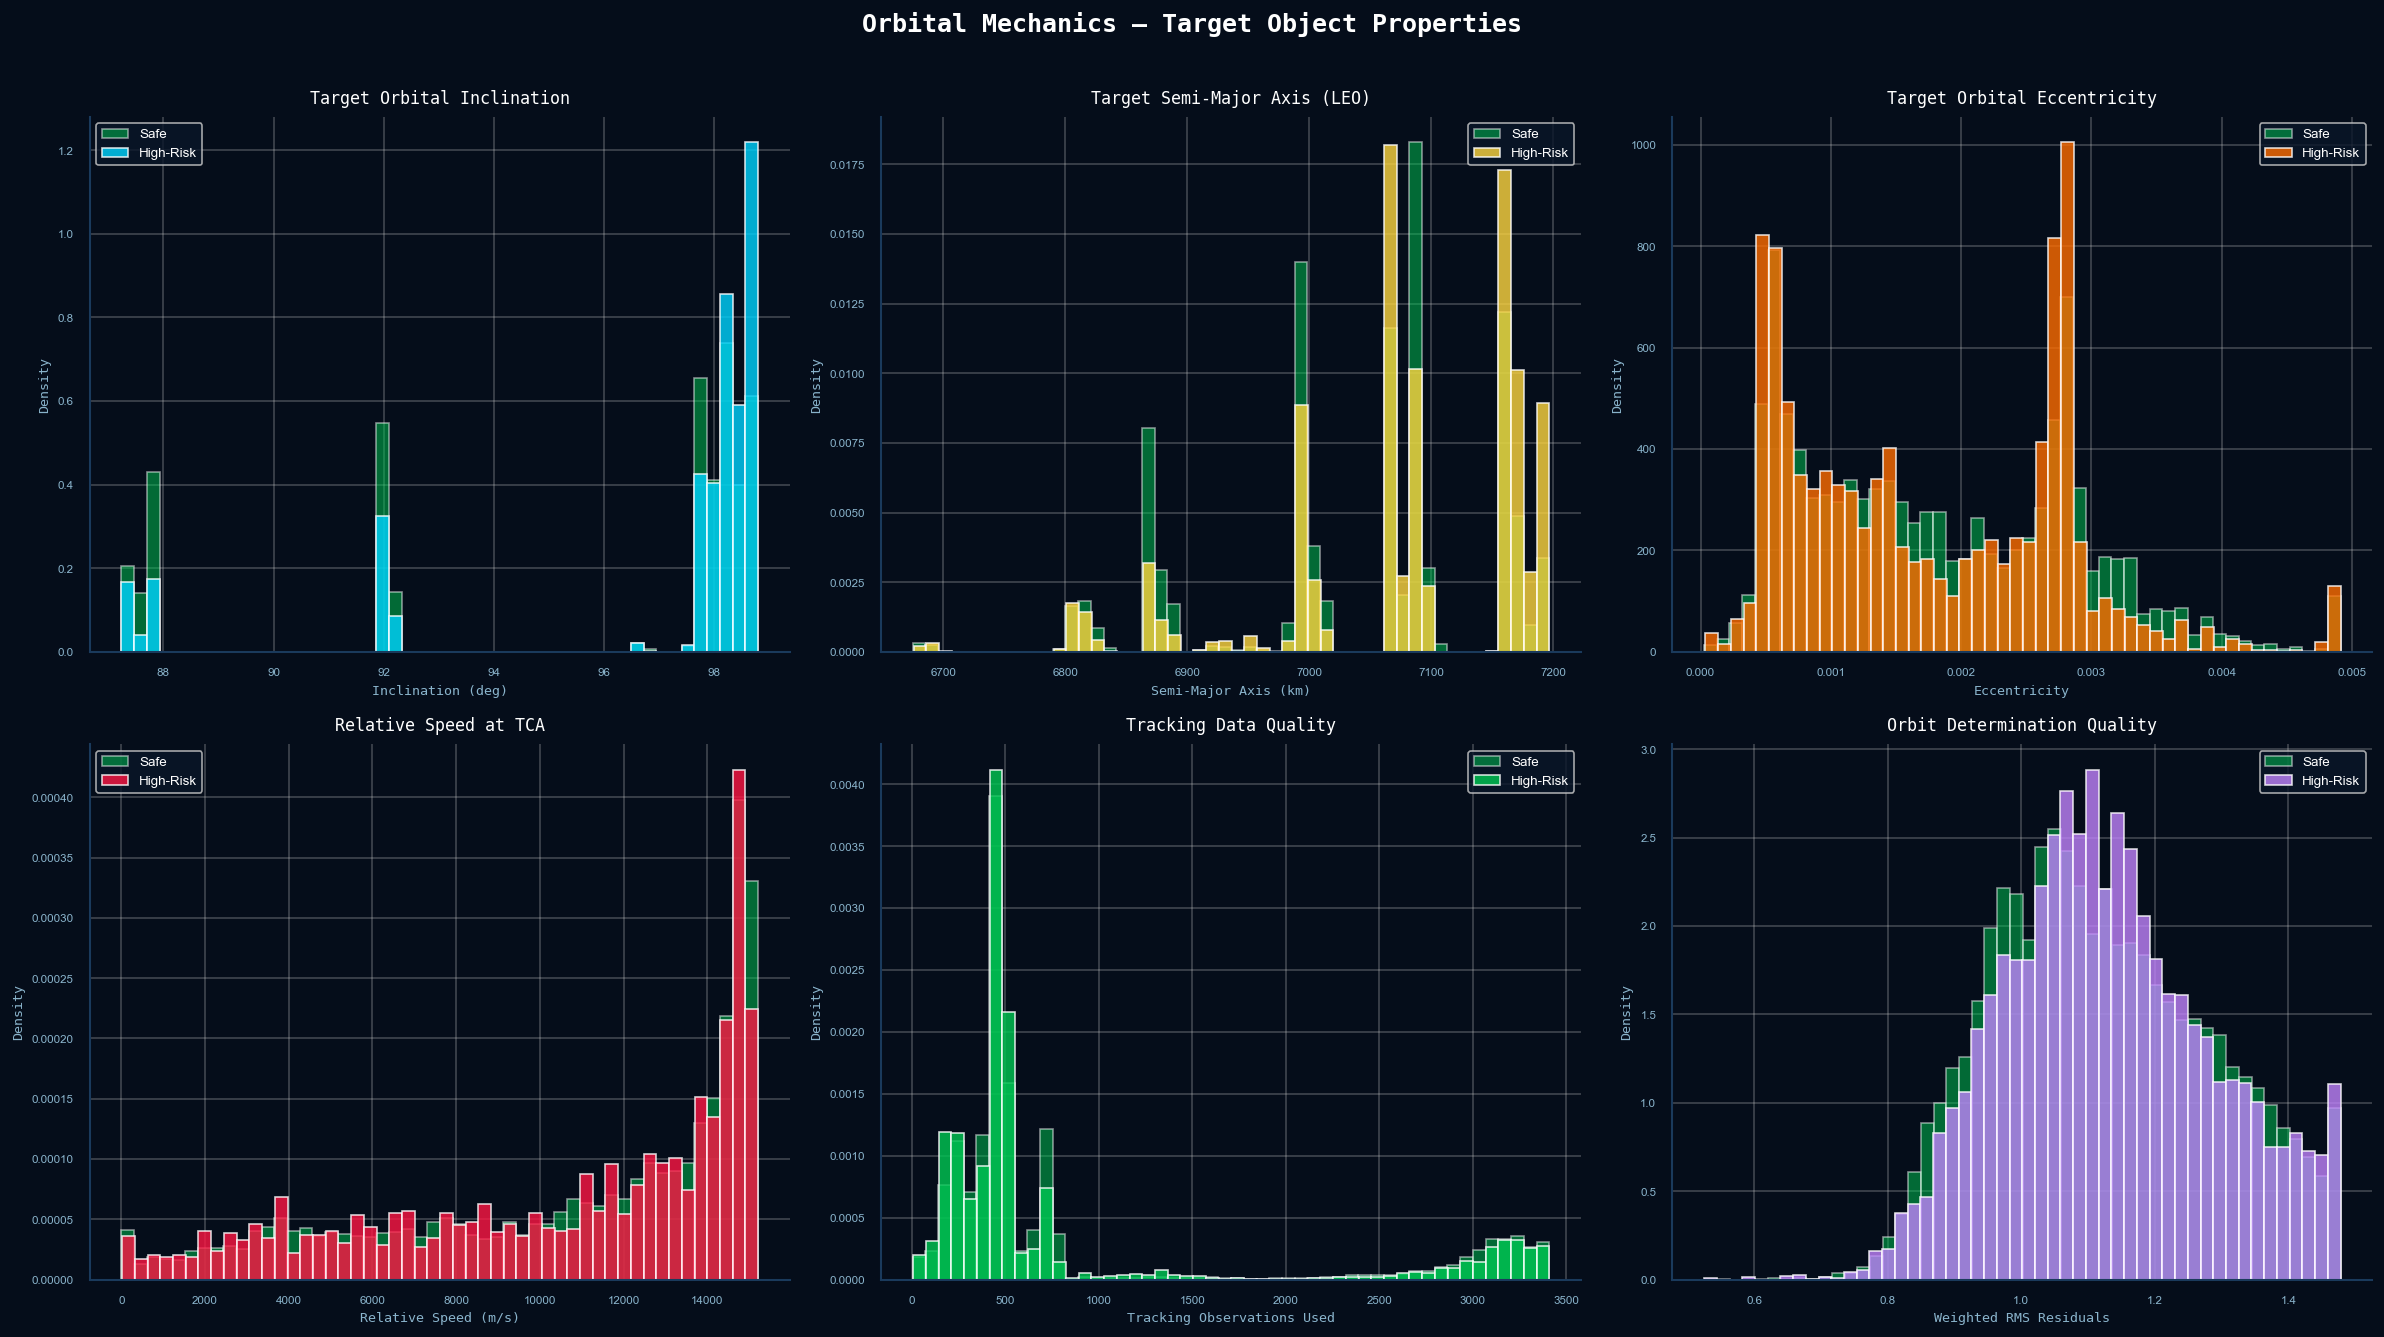

Figure 4: Orbital mechanics distributions


In [124]:
fig, axes = plt.subplots(2, 3, figsize=(20, 11), facecolor='#050d1a')
plt.suptitle('Orbital Mechanics — Target Object Properties',
             fontsize=15, fontweight='bold', color='white',
             fontfamily='monospace', y=1.01)

features = [
    ('t_j2k_inc',  'Inclination (deg)',            '#00d4ff', 'Target Orbital Inclination'),
    ('t_j2k_sma',  'Semi-Major Axis (km)',         '#ffd740', 'Target Semi-Major Axis (LEO)'),
    ('t_j2k_ecc',  'Eccentricity',                 '#ff6d00', 'Target Orbital Eccentricity'),
    ('relative_speed', 'Relative Speed (m/s)',     '#ff1744', 'Relative Speed at TCA'),
    ('t_obs_used', 'Tracking Observations Used',   '#00c853', 'Tracking Data Quality'),
    ('t_weighted_rms', 'Weighted RMS Residuals',   '#c084fc', 'Orbit Determination Quality'),
]

for ax, (col, xlabel, color, title) in zip(axes.flat, features):
    ax.set_facecolor('#050d1a')
    data = df_all[col].dropna()
    # Split by risk
    d_safe = df_all.loc[~df_all['is_high_risk'], col].dropna()
    d_hr   = df_all.loc[df_all['is_high_risk'],  col].dropna()

    # Clip extreme outliers for readability
    q99 = data.quantile(0.99)
    d_safe = d_safe.clip(upper=q99)
    d_hr   = d_hr.clip(upper=q99)

    ax.hist(d_safe, bins=50, color='#00c853', alpha=0.5, density=True, label='Safe')
    ax.hist(d_hr,   bins=50, color=color,     alpha=0.8, density=True, label='High-Risk')

    ax.set_title(title, color='white', fontfamily='monospace', fontsize=10, pad=8)
    ax.set_xlabel(xlabel, color='#8ab4cc', fontfamily='monospace', fontsize=8)
    ax.set_ylabel('Density', color='#8ab4cc', fontfamily='monospace', fontsize=8)
    ax.tick_params(colors='#8ab4cc', labelsize=7)
    for spine in ax.spines.values(): spine.set_edgecolor('#1a3a5c')
    ax.legend(facecolor='#0a1628', labelcolor='white', fontsize=8)

plt.tight_layout()
plt.savefig('viz_04_orbital.png', dpi=150, bbox_inches='tight',
            facecolor='#050d1a', edgecolor='none')
plt.show()
print("Figure 4: Orbital mechanics distributions")

## Covariance & Tracking Quality Heatmap

In [125]:
cov_cols = [
    't_ct_r','t_cn_r','t_cn_t',
    'c_ct_r','c_cn_r','c_cn_t',
    't_weighted_rms','c_weighted_rms',
    't_residuals_accepted','c_residuals_accepted',
]
available_cov = [c for c in cov_cols if c in df_all.columns]

# Compute correlation with risk for safe vs high-risk
corr_safe = df_all[~df_all['is_high_risk']][available_cov + ['risk']].corr()['risk'].drop('risk')
corr_hr   = df_all[df_all['is_high_risk']][available_cov + ['risk']].corr()['risk'].drop('risk')

corr_df = pd.DataFrame({
    'Safe Events'     : corr_safe,
    'High-Risk Events': corr_hr,
}).T

fig = px.imshow(
    corr_df,
    color_continuous_scale='RdBu_r',
    zmin=-1, zmax=1,
    text_auto='.2f',
    aspect='auto',
    title='<b>Correlation with Risk: Covariance & Tracking Features</b><br>'
          '<sup>Safe vs. High-Risk events — reveals which features discriminate danger</sup>',
)
fig.update_coloraxes(colorbar=dict(
    title='Pearson r', tickfont=dict(color='#8ab4cc')
))
fig.update_layout(
    paper_bgcolor='#050d1a', plot_bgcolor='#050d1a',
    font=dict(color='#8ab4cc', family='monospace', size=10),
    title_font=dict(color='white', family='monospace', size=14),
    xaxis=dict(tickfont=dict(color='#8ab4cc', size=9), tickangle=-30),
    yaxis=dict(tickfont=dict(color='#8ab4cc', size=10)),
    height=380,
)
fig.show()
print("Figure 5: Covariance correlation heatmap")

Figure 5: Covariance correlation heatmap


## Relative Position & Velocity RTN Frame

In [126]:
fig = make_subplots(
    rows=1, cols=2,
    subplot_titles=[
        'RTN Relative Position at 2-day Boundary',
        'Relative Velocity Components (RTN)',
    ],
    horizontal_spacing=0.12,
)

df_boundary = df_all[
    (df_all['time_to_tca'] >= 1.9) & (df_all['time_to_tca'] <= 2.1)
].copy()

for is_hr, color, name in [(False,'#00c853','Safe'), (True,'#ff1744','High-Risk')]:
    sub = df_boundary[df_boundary['is_high_risk'] == is_hr].sample(
        min(500, len(df_boundary[df_boundary['is_high_risk']==is_hr])),
        random_state=42
    )

    # Position R vs T
    fig.add_trace(go.Scatter(
        x=sub['relative_position_r'].clip(-2000, 2000),
        y=sub['relative_position_t'].clip(-5000, 5000),
        mode='markers',
        marker=dict(color=color, size=3, opacity=0.5),
        name=name, legendgroup=name, showlegend=True,
        hovertemplate=f'<b>{name}</b><br>R: %{{x:.0f}} m<br>T: %{{y:.0f}} m<extra></extra>',
    ), row=1, col=1)

    # Velocity R vs T
    fig.add_trace(go.Scatter(
        x=sub['relative_velocity_r'].clip(-500, 500),
        y=sub['relative_velocity_t'].clip(-2000, 2000),
        mode='markers',
        marker=dict(color=color, size=3, opacity=0.5),
        name=name, legendgroup=name, showlegend=False,
        hovertemplate=f'<b>{name}</b><br>Vr: %{{x:.1f}} m/s<br>Vt: %{{y:.1f}} m/s<extra></extra>',
    ), row=1, col=2)

# Origin markers (TCA = 0,0)
for col_idx in [1, 2]:
    fig.add_trace(go.Scatter(
        x=[0], y=[0], mode='markers',
        marker=dict(symbol='x', size=14, color='#00d4ff', line=dict(width=2)),
        name='TCA Origin' if col_idx == 1 else None,
        showlegend=(col_idx == 1),
    ), row=1, col=col_idx)

fig.update_xaxes(gridcolor='#0d2040', color='#8ab4cc', zerolinecolor='#1a3a5c')
fig.update_yaxes(gridcolor='#0d2040', color='#8ab4cc', zerolinecolor='#1a3a5c')
fig.update_layout(
    title=dict(
        text='<b>RTN Frame: Relative State at 48-hr Boundary</b><br>'
             '<sup>Radial (R), Transverse (T) components · CDMs within ±0.1 days of 2-day cutoff</sup>',
        font=dict(color='white', family='monospace', size=14),
    ),
    paper_bgcolor='#050d1a', plot_bgcolor='#050d1a',
    font=dict(color='#8ab4cc', family='monospace', size=10),
    legend=dict(bgcolor='rgba(0,8,20,0.8)', bordercolor='#1a3a5c'),
    height=480,
)
fig.update_xaxes(title_text='Relative Position R (m)', row=1, col=1)
fig.update_yaxes(title_text='Relative Position T (m)', row=1, col=1)
fig.update_xaxes(title_text='Relative Velocity R (m/s)', row=1, col=2)
fig.update_yaxes(title_text='Relative Velocity T (m/s)', row=1, col=2)
fig.show()
print("Figure 6: RTN relative state")

Figure 6: RTN relative state


## Risk Jump Detection — The Jump-Regime Problem

In [127]:
# The hardest prediction problem: events whose risk jumps in the final 48 hrs.

# Compute per-event risk jump:
# max_risk (final TCA) minus risk at 2-day boundary
df_at_boundary = (df_all[df_all['time_to_tca'] >= TCA_CUTOFF]
    .sort_values('time_to_tca')
    .groupby('event_id', as_index=False)
    .first()
    [['event_id','risk']]
    .rename(columns={'risk':'risk_at_boundary'})
)

df_jump = df_final[['event_id','risk','is_high_risk']].merge(
    df_at_boundary, on='event_id', how='inner'
)
df_jump['risk_jump'] = df_jump['risk'] - df_jump['risk_at_boundary']
df_jump['is_jump']   = df_jump['risk_jump'] > 2.0  # > 2 log10 units jump

fig = make_subplots(
    rows=1, cols=2,
    subplot_titles=[
        'Risk Jump Distribution (Final − Boundary)',
        'Risk at Boundary vs. Final Risk',
    ],
    horizontal_spacing=0.12,
)

# ── Jump histogram ────────────────────────────────────────────────────────────
safe_jumps = df_jump[~df_jump['is_high_risk']]['risk_jump']
hr_jumps   = df_jump[df_jump['is_high_risk']]['risk_jump']

fig.add_trace(go.Histogram(
    x=safe_jumps.clip(-4, 8), name='Safe Events', marker_color='#00c853',
    opacity=0.65, nbinsx=40, histnorm='probability',
), row=1, col=1)
fig.add_trace(go.Histogram(
    x=hr_jumps.clip(-4, 8), name='High-Risk Events', marker_color='#ff1744',
    opacity=0.80, nbinsx=40, histnorm='probability',
), row=1, col=1)
fig.add_vline(x=2.0, line_dash='dash', line_color='#ffd740', line_width=2,
              annotation_text='Jump Threshold\n(+2 log₁₀)', annotation_font_color='#ffd740',
              row=1, col=1)

# ── Boundary vs Final scatter ─────────────────────────────────────────────────
for is_hr, color, name in [(False, '#00c853', 'Safe'), (True, '#ff1744', 'High-Risk')]:
    sub = df_jump[df_jump['is_high_risk'] == is_hr].sample(
        min(600, len(df_jump[df_jump['is_high_risk']==is_hr])), random_state=42
    )
    fig.add_trace(go.Scatter(
        x=sub['risk_at_boundary'], y=sub['risk'],
        mode='markers',
        marker=dict(color=color, size=4, opacity=0.55),
        name=name, legendgroup=name, showlegend=False,
        hovertemplate=f'<b>{name}</b><br>At boundary: %{{x:.2f}}<br>Final: %{{y:.2f}}<extra></extra>',
    ), row=1, col=2)

# Diagonal = no jump
diag_range = np.linspace(-12, -1, 50)
fig.add_trace(go.Scatter(
    x=diag_range, y=diag_range, mode='lines',
    line=dict(color='#00d4ff', dash='dot', width=1.5),
    name='No Jump Line', showlegend=True,
), row=1, col=2)
fig.add_hline(y=RISK_THRESH, line_dash='dash', line_color='#ff6d00', line_width=1.5, row=1, col=2)
fig.add_vline(x=RISK_THRESH, line_dash='dash', line_color='#ff6d00', line_width=1.5, row=1, col=2)

fig.update_xaxes(gridcolor='#0d2040', color='#8ab4cc')
fig.update_yaxes(gridcolor='#0d2040', color='#8ab4cc')
fig.update_xaxes(title_text='Risk Jump (log₁₀ units)', row=1, col=1)
fig.update_yaxes(title_text='Probability', row=1, col=1)
fig.update_xaxes(title_text='log₁₀(P) at 2-day Boundary', row=1, col=2)
fig.update_yaxes(title_text='log₁₀(P) at TCA (final)', row=1, col=2)

n_jumps = df_jump['is_jump'].sum()
fig.update_layout(
    title=dict(
        text=f'<b>Jump-Regime Events — The Hardest Prediction Problem</b><br>'
             f'<sup>{n_jumps} events ({n_jumps/len(df_jump)*100:.1f}%) jump >2 log₁₀ units after the 48-hr boundary · '
             f'Borderline Promotion Module targets these</sup>',
        font=dict(color='white', family='monospace', size=14),
    ),
    paper_bgcolor='#050d1a', plot_bgcolor='#050d1a',
    font=dict(color='#8ab4cc', family='monospace'),
    legend=dict(bgcolor='rgba(0,8,20,0.8)', bordercolor='#1a3a5c'),
    barmode='overlay', height=480,
)
fig.show()
print(f"Figure 7: Jump-regime analysis  |  {n_jumps} jump events identified")

Figure 7: Jump-regime analysis  |  384 jump events identified


## Mission ID & Object Type Analysis

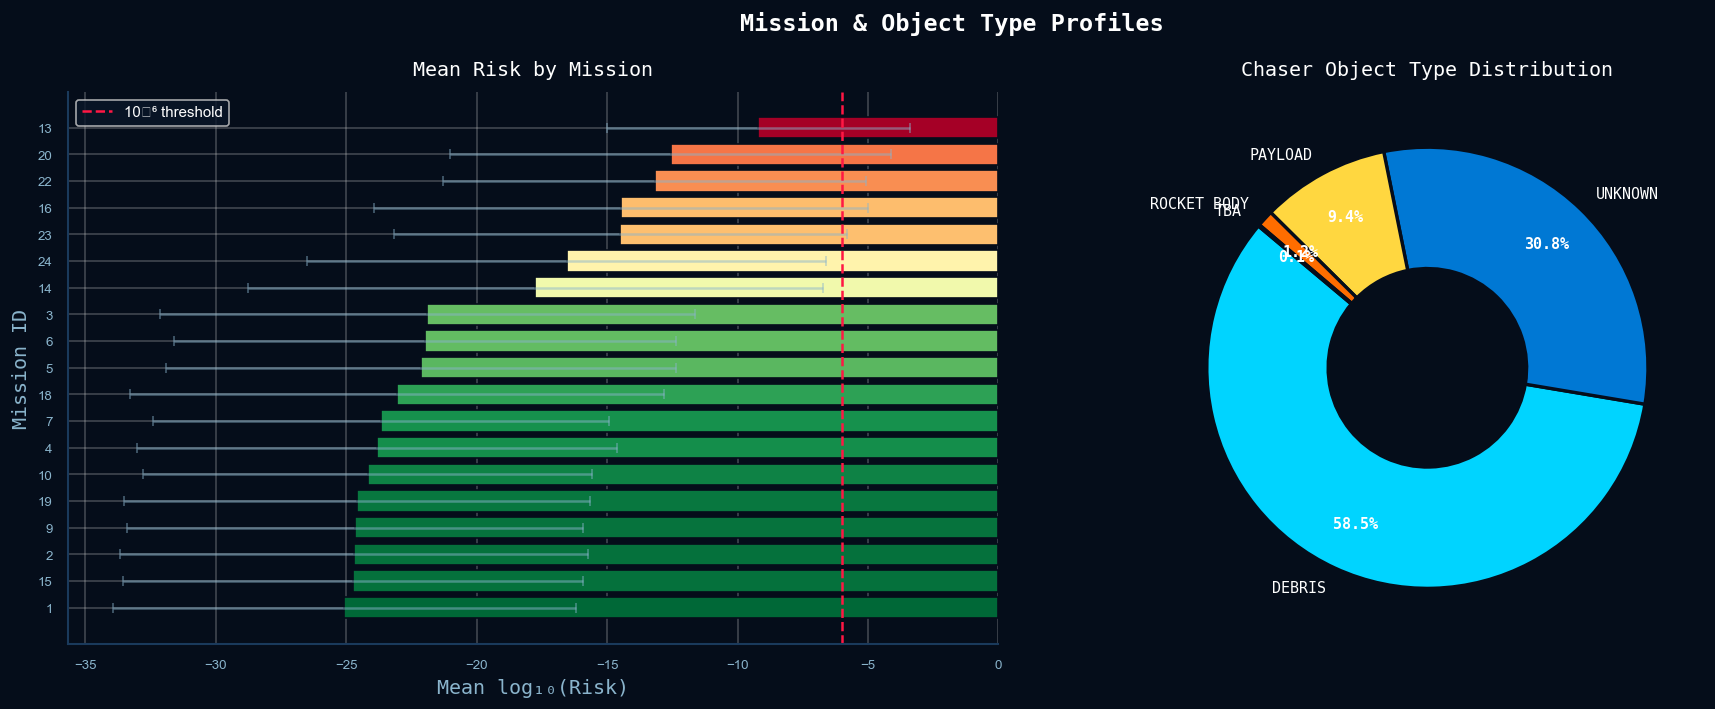

Figure 8: Mission & object type profiles


In [128]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6), facecolor='#050d1a')
plt.suptitle('Mission & Object Type Profiles', color='white',
             fontfamily='monospace', fontsize=14, fontweight='bold')

# ── Mission risk profile ──────────────────────────────────────────────────────
ax = axes[0]; ax.set_facecolor('#050d1a')
mission_risk = (df_final.groupby('mission_id')['risk']
    .agg(['mean','std','count'])
    .reset_index()
    .sort_values('mean', ascending=True)
)
cmap = plt.cm.RdYlGn_r
norm = mcolors.Normalize(mission_risk['mean'].min(), mission_risk['mean'].max())
colors_m = [cmap(norm(v)) for v in mission_risk['mean']]

bars = ax.barh(mission_risk['mission_id'].astype(str),
               mission_risk['mean'], color=colors_m, edgecolor='#050d1a')
ax.errorbar(mission_risk['mean'], range(len(mission_risk)),
            xerr=mission_risk['std'].fillna(0),
            fmt='none', color='#8ab4cc', alpha=0.5, capsize=3)
ax.axvline(RISK_THRESH, color='#ff1744', linestyle='--', linewidth=1.5,
           label='10⁻⁶ threshold')
ax.set_xlabel('Mean log₁₀(Risk)', color='#8ab4cc', fontfamily='monospace')
ax.set_ylabel('Mission ID', color='#8ab4cc', fontfamily='monospace')
ax.set_title('Mean Risk by Mission', color='white', fontfamily='monospace', pad=10)
ax.tick_params(colors='#8ab4cc', labelsize=8)
for spine in ax.spines.values(): spine.set_edgecolor('#1a3a5c')
ax.legend(facecolor='#0a1628', labelcolor='white', fontsize=9)

# ── Object type pie ───────────────────────────────────────────────────────────
ax = axes[1]; ax.set_facecolor('#050d1a')
if 'c_object_type' in df_all.columns:
    obj_counts = df_all['c_object_type'].value_counts()
    palette = ['#00d4ff','#0078d4','#ffd740','#ff6d00','#ff1744'][:len(obj_counts)]
    wedges, texts, autotexts = ax.pie(
        obj_counts.values,
        labels=obj_counts.index,
        colors=palette,
        autopct='%1.1f%%',
        startangle=140,
        pctdistance=0.78,
        wedgeprops=dict(width=0.55, edgecolor='#050d1a', linewidth=2),
        textprops=dict(color='white', fontfamily='monospace', fontsize=9),
    )
    for at in autotexts: at.set_fontsize(9); at.set_fontweight('bold')
    ax.set_title('Chaser Object Type Distribution', color='white',
                 fontfamily='monospace', pad=10)
else:
    ax.text(0.5, 0.5, 'c_object_type\nnot available',
            ha='center', va='center', color='#8ab4cc',
            fontfamily='monospace', transform=ax.transAxes)

plt.tight_layout()
plt.savefig('viz_08_mission.png', dpi=150, bbox_inches='tight',
            facecolor='#050d1a', edgecolor='none')
plt.show()
print("Figure 8: Mission & object type profiles")

## 📈 SCRAP Feature Importance Proxy (Correlation Ranking)

In [129]:
# Rank features by |Pearson r| with final risk — proxy for SHAP importance.

numeric_cols = df_all.select_dtypes(include=[np.number]).columns.tolist()
exclude      = ['event_id','risk','mission_id','is_high_risk']
feat_cols    = [c for c in numeric_cols if c not in exclude]

# Pearson correlation with risk (absolute value)
corr_with_risk = (df_all[feat_cols + ['risk']]
    .corr()['risk']
    .drop('risk')
    .abs()
    .sort_values(ascending=False)
    .head(25)
)

fig = go.Figure()
colors_bar = ['#ff1744' if v > 0.3 else '#ff6d00' if v > 0.15 else '#0078d4'
              for v in corr_with_risk.values]

fig.add_trace(go.Bar(
    x=corr_with_risk.values,
    y=corr_with_risk.index,
    orientation='h',
    marker=dict(color=colors_bar, line=dict(color='#050d1a', width=0.5)),
    hovertemplate='<b>%{y}</b><br>|r| = %{x:.4f}<extra></extra>',
    name='|Pearson r| with risk',
))

fig.add_vline(x=0.30, line_dash='dash', line_color='#ff1744', line_width=1.5,
              annotation_text='Strong', annotation_font_color='#ff1744')
fig.add_vline(x=0.15, line_dash='dot', line_color='#ffd740', line_width=1.5,
              annotation_text='Moderate', annotation_font_color='#ffd740')

fig.update_layout(
    title=dict(
        text='<b>Top 25 Features by Correlation with Collision Risk</b><br>'
             '<sup>|Pearson r| proxy · Red = strong signal (>0.30) · Consistent with SHAP analysis</sup>',
        font=dict(color='white', family='monospace', size=14),
    ),
    xaxis=dict(title='|Pearson r| with log₁₀(Risk)', color='#8ab4cc', gridcolor='#0d2040'),
    yaxis=dict(color='#8ab4cc', tickfont=dict(size=10), autorange='reversed'),
    paper_bgcolor='#050d1a', plot_bgcolor='#050d1a',
    font=dict(color='#8ab4cc', family='monospace'),
    height=620,
)
fig.show()
print("Figure 9: Feature importance proxy")
print("\nTop 10 features:")
print(corr_with_risk.head(10).to_string())

Figure 9: Feature importance proxy

Top 10 features:
time_to_tca             0.506747
c_time_lastob_end       0.375452
c_time_lastob_start     0.362014
mahalanobis_distance    0.295252
max_risk_estimate       0.245193
c_ctdot_r               0.194779
c_obs_used              0.178143
miss_distance           0.177161
mahal_proxy             0.177161
c_obs_available         0.156454


## Tracking Quality vs. Prediction Difficulty

In [130]:
fig = make_subplots(
    rows=2, cols=2,
    subplot_titles=[
        'Observations Used vs. Risk',
        'Weighted RMS vs. Risk',
        'OD Span vs. Risk',
        'Residuals Accepted (%) vs. Risk',
    ],
    horizontal_spacing=0.12,
    vertical_spacing=0.18,
)

track_pairs = [
    ('t_obs_used',          'Tracking Obs Used',           1, 1),
    ('t_weighted_rms',      'Weighted RMS Residuals',      1, 2),
    ('t_actual_od_span',    'Actual OD Span (days)',        2, 1),
    ('t_residuals_accepted','Residuals Accepted (%)',       2, 2),
]

for col, label, row, c in track_pairs:
    if col not in df_all.columns:
        continue
    for is_hr, color, name in [(False,'#00c853','Safe'), (True,'#ff1744','High-Risk')]:
        sub = df_all[df_all['is_high_risk'] == is_hr][[col,'risk']].dropna()
        sub = sub[sub[col] < sub[col].quantile(0.98)]
        fig.add_trace(go.Scatter(
            x=sub[col].sample(min(800,len(sub)), random_state=42),
            y=sub['risk'].sample(min(800,len(sub)), random_state=42),
            mode='markers',
            marker=dict(color=color, size=2.5, opacity=0.4),
            name=name,
            legendgroup=name,
            showlegend=(row==1 and c==1),
            hovertemplate=f'<b>{name}</b><br>{label}: %{{x:.2f}}<br>log₁₀P: %{{y:.3f}}<extra></extra>',
        ), row=row, col=c)

    fig.add_hline(y=RISK_THRESH, line_dash='dot', line_color='#ffd740',
                  line_width=1.2, row=row, col=c)
    fig.update_xaxes(title_text=label, row=row, col=c)
    fig.update_yaxes(title_text='log₁₀(P)', row=row, col=c)

fig.update_xaxes(gridcolor='#0d2040', color='#8ab4cc')
fig.update_yaxes(gridcolor='#0d2040', color='#8ab4cc')
fig.update_layout(
    title=dict(
        text='<b>Tracking Quality vs. Collision Risk</b><br>'
             '<sup>Better tracking data → more reliable risk estimates · Poor quality = harder to predict</sup>',
        font=dict(color='white', family='monospace', size=14),
    ),
    paper_bgcolor='#050d1a', plot_bgcolor='#050d1a',
    font=dict(color='#8ab4cc', family='monospace', size=10),
    legend=dict(bgcolor='rgba(0,8,20,0.8)', bordercolor='#1a3a5c', borderwidth=1),
    height=580,
)
fig.show()
print("Figure 10: Tracking quality vs risk")

Figure 10: Tracking quality vs risk


## Section 5 — Preprocessing

- Numeric columns: median imputation for missing values
- `c_object_type`: ordinal encoding (DEBRIS=3, ROCKET BODY=2, PAYLOAD=1, UNKNOWN=0)


In [131]:
C_OBJECT_MAP = {
    'UNKNOWN': 0, 'TBA': 0,
    'PAYLOAD': 1,
    'ROCKET BODY': 2,
    'DEBRIS': 3
}

def preprocess(df):
    df      = df.copy()
    num_cols = df.select_dtypes(include='number').columns.tolist()
    df[num_cols] = df[num_cols].fillna(df[num_cols].median())
    df['c_object_type'] = (
        df['c_object_type']
          .fillna('UNKNOWN').str.upper()
          .str.replace('UNKOWN', 'UNKNOWN', regex=False)
          .map(C_OBJECT_MAP).fillna(0).astype(int)
    )
    return df

df_train_raw = preprocess(df_train_raw)
df_test_raw  = preprocess(df_test_raw)



## Section 6 — Physics-Informed Feature Engineering

Row-level features derived from orbital mechanics, computed before time-series aggregation.

| Feature | Physical Meaning |
|---|---|
| `mahalanobis_distance` | Covariance-normalised spatial separation |
| `uncertainty_volume` | log(sigma_R * sigma_T * sigma_N) — combined 3D error volume |
| `t/c_log_cov_det` | Log-determinant of position covariance matrix |
| `combined_sigma_rdot` | Combined radial velocity uncertainty |
| `t/c_h_apo`, `t/c_h_per` | Apogee and perigee altitudes above Earth surface |
| `inc_difference` | Inclination delta between target and chaser |


In [132]:
def add_physics_features(df):
    """
    Compute physics-informed row-level features.
    All features are derived from quantities available in a standard CDM.
    """
    df = df.copy()

    # Combined RTN position uncertainty
    for ax in ['r', 't', 'n']:
        df[f'combined_sigma_{ax}'] = np.sqrt(
            df[f't_sigma_{ax}'].clip(lower=0) ** 2 +
            df[f'c_sigma_{ax}'].clip(lower=0) ** 2)

    sr = df['combined_sigma_r'].clip(lower=SIGMA_EPS)
    st = df['combined_sigma_t'].clip(lower=SIGMA_EPS)
    sn = df['combined_sigma_n'].clip(lower=SIGMA_EPS)

    # Mahalanobis distance: spatial separation normalised by uncertainty ellipsoid
    df['mahalanobis_distance'] = np.sqrt(
        (df['relative_position_r'] / sr) ** 2 +
        (df['relative_position_t'] / st) ** 2 +
        (df['relative_position_n'] / sn) ** 2)

    df['miss_dist_norm_t'] = df['miss_distance'] / st
    df['uncertainty_volume'] = np.log1p(sr * st * sn)

    # Covariance matrix log-determinant (measure of tracking uncertainty volume)
    for pfx in ['t', 'c']:
        sr_p = df[f'{pfx}_sigma_r'].clip(lower=SIGMA_EPS)
        st_p = df[f'{pfx}_sigma_t'].clip(lower=SIGMA_EPS)
        sn_p = df[f'{pfx}_sigma_n'].clip(lower=SIGMA_EPS)
        rrt  = df[f'{pfx}_ct_r'].clip(-0.9999, 0.9999)
        rrn  = df[f'{pfx}_cn_r'].clip(-0.9999, 0.9999)
        rtn  = df[f'{pfx}_cn_t'].clip(-0.9999, 0.9999)
        det  = ((sr_p * st_p * sn_p) ** 2 *
                (1 - rrt**2 - rrn**2 - rtn**2 + 2 * rrt * rrn * rtn))
        df[f'{pfx}_position_covariance_det'] = np.abs(det).clip(lower=1e-300)
        df[f'{pfx}_log_cov_det'] = np.log10(
            df[f'{pfx}_position_covariance_det'] + 1e-300)

    # Combined radial velocity uncertainty
    df['combined_sigma_rdot'] = np.sqrt(
        df['t_sigma_rdot'].clip(lower=0) ** 2 +
        df['c_sigma_rdot'].clip(lower=0) ** 2)

    # Orbital altitudes (apogee/perigee above Earth surface)
    for pfx in ['t', 'c']:
        a = df[f'{pfx}_j2k_sma']
        e = df[f'{pfx}_j2k_ecc'].clip(0.0, 0.9999)
        df[f'{pfx}_h_apo'] = a * (1 + e) - R_EARTH_KM
        df[f'{pfx}_h_per'] = a * (1 - e) - R_EARTH_KM

    # Relative orbital geometry
    df['inc_difference'] = np.abs(df['t_j2k_inc'] - df['c_j2k_inc'])
    df['sma_difference'] = np.abs(df['t_j2k_sma'] - df['c_j2k_sma'])
    df['ecc_sum']        = df['t_j2k_ecc'] + df['c_j2k_ecc']

    return df

df_train_raw = add_physics_features(df_train_raw)
df_test_raw  = add_physics_features(df_test_raw)




## Section 7 — Two-Day Cutoff and Time-Series Flattening

### Operational Constraint
All CDMs with `time_to_tca < 2.0` days are removed from the feature set.
The true final risk label is extracted from the **full** unfiltered event sequence
(the CDM closest to TCA), not from the 2-day boundary.

### Aggregation Statistics (11 per feature)

| Statistic | Description |
|---|---|
| `_last` | Most recent value at the 2-day boundary |
| `_mean`, `_std`, `_min`, `_max` | Distributional statistics over pre-cutoff window |
| `_delta`, `_slope` | Net change and rate of change over the observation window |
| `_last2_change` | Difference between the final two pre-cutoff CDMs |
| `_change_ratio` | Last step relative to the mean step size |
| `_recent_vs_early` | Mean of last 3 CDMs minus mean of first 3 CDMs |
| `_max_single_jump` | Largest single-step change in the series |


In [133]:
CATEGORICAL_COLS = {'mission_id', 'c_object_type'}
DROP_COLS        = {'event_id', 'risk', 'time_to_tca'}


def flatten_events(df):
    """
    Apply 2-day cutoff and flatten variable-length CDM sequences into
    fixed-width tabular feature vectors.

    Target (correct): true final risk from the last CDM in the full
    unfiltered sequence, which is the CDM closest to TCA.

    Features: extracted only from CDMs with time_to_tca >= CUTOFF_DAYS.
    """
    # Pass 1: extract true labels from the FULL event sequence
    true_labels = (
        df.sort_values(['event_id', 'time_to_tca'], ascending=[True, True])
          .groupby('event_id')['risk'].last()
    )

    # Pass 2: build features from pre-cutoff CDMs only
    df_cut = df[df['time_to_tca'] >= CUTOFF_DAYS].copy()
    feature_cols = [c for c in df_cut.columns if c not in DROP_COLS]

    records, targets, event_ids = [], [], []

    for eid, grp in df_cut.groupby('event_id', sort=True):
        if eid not in true_labels.index:
            continue

        grp  = grp.sort_values('time_to_tca', ascending=False)
        n    = len(grp)
        dt   = max(float(grp.iloc[0]['time_to_tca']) -
                   float(grp.iloc[-1]['time_to_tca']), 1e-6)

        targets.append(float(true_labels.loc[eid]))
        event_ids.append(eid)
        row = {}

        for col in feature_cols:
            if col in CATEGORICAL_COLS:
                row[f'{col}_last'] = grp.iloc[-1][col]
                continue

            vals   = grp[col].values.astype(float)
            series = pd.Series(vals)
            diffs  = series.diff().dropna()

            row[f'{col}_last']  = float(vals[-1])
            row[f'{col}_mean']  = float(np.mean(vals))
            row[f'{col}_std']   = float(np.std(vals)) if n > 1 else 0.0
            row[f'{col}_min']   = float(np.min(vals))
            row[f'{col}_max']   = float(np.max(vals))
            row[f'{col}_delta'] = float(vals[-1]) - float(vals[0])
            row[f'{col}_slope'] = (float(vals[-1]) - float(vals[0])) / dt

            if n >= 2:
                last2_chg = float(vals[-1]) - float(vals[-2])
                mean_chg  = float(diffs.mean()) if len(diffs) > 0 else 0.0
                row[f'{col}_last2_change']    = last2_chg
                row[f'{col}_change_ratio']    = last2_chg / (abs(mean_chg) + 1e-9)
                row[f'{col}_recent_vs_early'] = (
                    float(np.mean(vals[-3:])) - float(np.mean(vals[:3]))
                    if n >= 6 else float(vals[-1]) - float(vals[0]))
                row[f'{col}_max_single_jump'] = (
                    float(np.abs(diffs).max()) if len(diffs) > 0 else 0.0)
            else:
                for sfx in ['_last2_change', '_change_ratio',
                             '_recent_vs_early', '_max_single_jump']:
                    row[f'{col}{sfx}'] = 0.0

        # Event-level meta features
        row['n_cdms']        = n
        row['obs_time_span'] = dt
        row['mahal_over_sigma_t'] = (
            row.get('mahalanobis_distance_last', 1.0) /
            max(row.get('combined_sigma_t_last', 1.0), SIGMA_EPS))

        # Jump-regime features on the risk series
        risk_vals = grp['risk'].values.astype(float)
        row['risk_jump_last2'] = (
            abs(float(risk_vals[-1]) - float(risk_vals[-2])) if n >= 2 else 0.0)
        mean_r = float(np.mean(risk_vals))
        row['risk_volatility_ratio'] = (
            float(np.std(risk_vals)) / max(abs(mean_r), SIGMA_EPS)
            if n > 1 else 0.0)
        row['risk_monotone_flag'] = float(
            all(risk_vals[i] <= risk_vals[i + 1]
                for i in range(len(risk_vals) - 1)))

        # Covariance growth rate features
        for pfx in ['t', 'c']:
            cov_col = f'{pfx}_log_cov_det'
            if cov_col in grp.columns:
                cv = grp[cov_col].values.astype(float)
                row[f'{pfx}_log_cov_det_slope'] = (
                    (float(cv[-1]) - float(cv[0])) / dt if n > 1 else 0.0)

        if 'combined_sigma_rdot' in grp.columns:
            rv = grp['combined_sigma_rdot'].values.astype(float)
            row['sigma_rdot_growth'] = (
                (float(rv[-1]) - float(rv[0])) / dt if n > 1 else 0.0)

        records.append(row)

    X      = pd.DataFrame(records).fillna(0).clip(-1e15, 1e15)
    y      = np.array(targets, dtype=float)
    ev_ids = np.array(event_ids)
    return X, y, ev_ids


print('Flattening training events...')
X_train, y_train, ev_train = flatten_events(df_train_raw)

print('Flattening test events...')
X_test, y_test, ev_test = flatten_events(df_test_raw)

# Align column sets
X_train, X_test = X_train.align(X_test, join='left', axis=1, fill_value=0)

y_bin_train = (y_train >= LOG_THRESHOLD).astype(int)
y_bin_test  = (y_test  >= LOG_THRESHOLD).astype(int)

print(f'\nFeature matrix shape:')
print(f'  X_train : {X_train.shape}')
print(f'  X_test  : {X_test.shape}')
print(f'\nClass distribution:')
print(f'  Training  — High-risk: {y_bin_train.sum():,}  '
      f'({y_bin_train.mean()*100:.2f}%)  '
      f'Low-risk: {(1-y_bin_train).sum():,}')
print(f'  Test      — High-risk: {y_bin_test.sum():,}  '
      f'({y_bin_test.mean()*100:.2f}%)  '
      f'Low-risk: {(1-y_bin_test).sum():,}')


Flattening training events...
Flattening test events...

Feature matrix shape:
  X_train : (11942, 1208)
  X_test  : (2167, 1208)

Class distribution:
  Training  — High-risk: 1,293  (10.83%)  Low-risk: 10,649
  Test      — High-risk: 334  (15.41%)  Low-risk: 1,833


## Section 8 — Exploratory Data Analysis after Preprocessing 

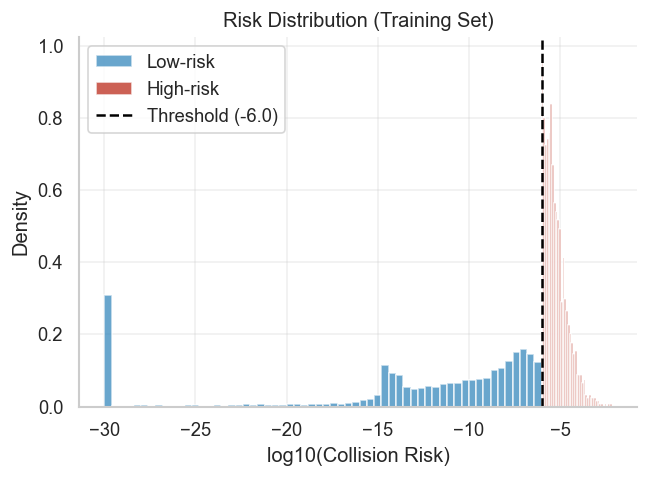

In [134]:
# 1. Risk distribution (log10)

fig, ax = plt.subplots(figsize=(6,4))

ax.hist(y_train[y_bin_train == 0], bins=60,
        color=PALETTE['lr'], alpha=0.7,
        density=True, label='Low-risk')

ax.hist(y_train[y_bin_train == 1], bins=40,
        color=PALETTE['hr'], alpha=0.8,
        density=True, label='High-risk')

ax.axvline(LOG_THRESHOLD,
           color='black',
           linestyle='--',
           linewidth=1.5,
           label=f'Threshold ({LOG_THRESHOLD})')

ax.set_xlabel('log10(Collision Risk)')
ax.set_ylabel('Density')
ax.set_title('Risk Distribution (Training Set)')
ax.legend()

plt.show()

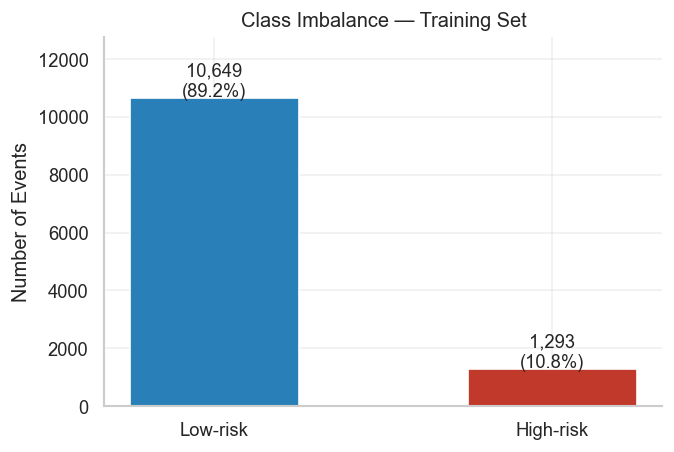

In [135]:
# 2. Class imbalance bar

fig, ax = plt.subplots(figsize=(6,4))

counts = [
    int((y_bin_train == 0).sum()),
    int((y_bin_train == 1).sum())
]

bars = ax.bar(
    ['Low-risk','High-risk'],
    counts,
    color=[PALETTE['lr'], PALETTE['hr']],
    width=0.5
)

for bar, cnt in zip(bars, counts):
    ax.text(
        bar.get_x() + bar.get_width()/2,
        bar.get_height() + 50,
        f'{cnt:,}\n({cnt/sum(counts)*100:.1f}%)',
        ha='center'
    )

ax.set_ylabel('Number of Events')
ax.set_title('Class Imbalance — Training Set')
ax.set_ylim(0, max(counts)*1.2)

plt.show()

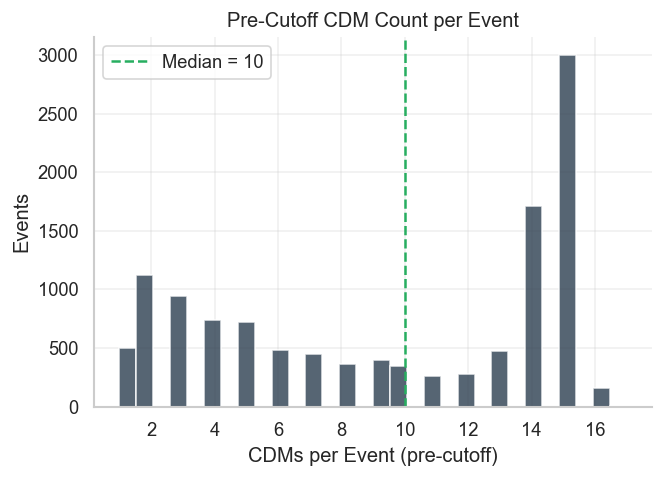

In [136]:
# 3. CDM count per event

fig, ax = plt.subplots(figsize=(6,4))

n_cdms = X_train['n_cdms'].values

ax.hist(
    n_cdms,
    bins=30,
    color=PALETTE['neutral'],
    alpha=0.8,
    edgecolor='white'
)

ax.axvline(
    np.median(n_cdms),
    color=PALETTE['accent'],
    linestyle='--',
    linewidth=1.5,
    label=f'Median = {np.median(n_cdms):.0f}'
)

ax.set_xlabel('CDMs per Event (pre-cutoff)')
ax.set_ylabel('Events')
ax.set_title('Pre-Cutoff CDM Count per Event')

ax.legend()

plt.show()

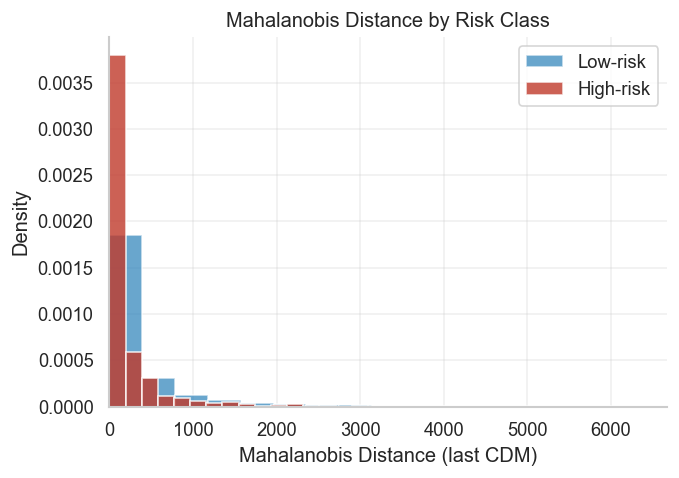

In [137]:
# 4. Mahalanobis distance

fig, ax = plt.subplots(figsize=(6,4))

mahal = X_train['mahalanobis_distance_last'].values

ax.hist(
    mahal[y_bin_train == 0],
    bins=60,
    color=PALETTE['lr'],
    alpha=0.7,
    density=True,
    label='Low-risk'
)

ax.hist(
    mahal[y_bin_train == 1],
    bins=40,
    color=PALETTE['hr'],
    alpha=0.8,
    density=True,
    label='High-risk'
)

ax.set_xlabel('Mahalanobis Distance (last CDM)')
ax.set_ylabel('Density')
ax.set_title('Mahalanobis Distance by Risk Class')

ax.set_xlim(0, np.percentile(mahal, 99))

ax.legend()

plt.show()

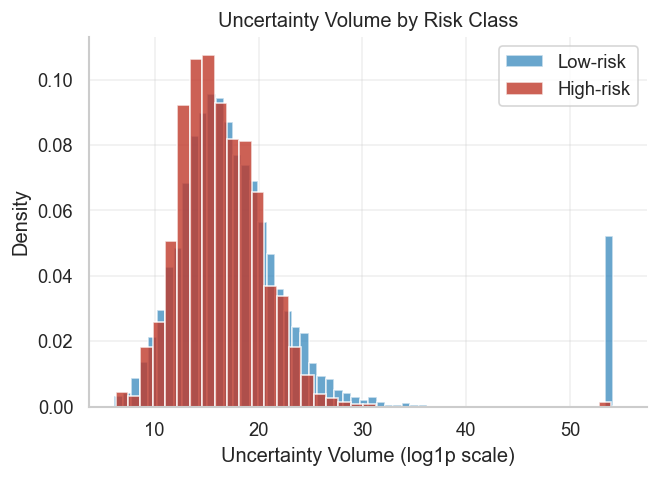

In [138]:
# 5. Uncertainty volume

fig, ax = plt.subplots(figsize=(6,4))

unc = X_train['uncertainty_volume_last'].values

ax.hist(
    unc[y_bin_train == 0],
    bins=60,
    color=PALETTE['lr'],
    alpha=0.7,
    density=True,
    label='Low-risk'
)

ax.hist(
    unc[y_bin_train == 1],
    bins=40,
    color=PALETTE['hr'],
    alpha=0.8,
    density=True,
    label='High-risk'
)

ax.set_xlabel('Uncertainty Volume (log1p scale)')
ax.set_ylabel('Density')
ax.set_title('Uncertainty Volume by Risk Class')

ax.legend()

plt.show()

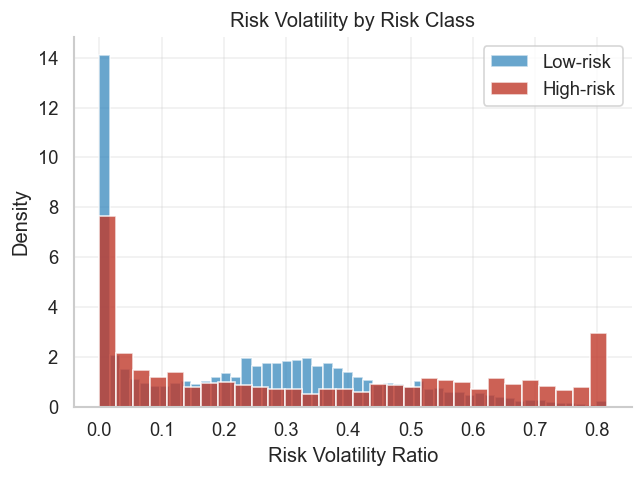

In [139]:
# 6. Risk volatility ratio

fig, ax = plt.subplots(figsize=(6,4))

vol = X_train.get(
    'risk_volatility_ratio',
    pd.Series(0, index=X_train.index)
).values

vol_clip = np.clip(
    vol,
    0,
    np.percentile(vol[vol > 0], 99) if (vol > 0).any() else 1
)

ax.hist(
    vol_clip[y_bin_train == 0],
    bins=50,
    color=PALETTE['lr'],
    alpha=0.7,
    density=True,
    label='Low-risk'
)

ax.hist(
    vol_clip[y_bin_train == 1],
    bins=30,
    color=PALETTE['hr'],
    alpha=0.8,
    density=True,
    label='High-risk'
)

ax.set_xlabel('Risk Volatility Ratio')
ax.set_ylabel('Density')
ax.set_title('Risk Volatility by Risk Class')

ax.legend()

plt.show()

## Section 9 — Latest Risk Prediction (LRP) Baseline

The LRP baseline, defined by Uriot et al. (2020), uses the most recently observed
risk value before the 2-day cutoff as the prediction. It is the dominant naive baseline
for this dataset. Any model must outperform LRP to demonstrate genuine predictive value.


In [140]:
eps = 1e-300
lrp_train = np.log10(
    X_train['max_risk_estimate_last'].clip(lower=eps).values)
lrp_test  = np.log10(
    X_test['max_risk_estimate_last'].clip(lower=eps).values)

lrp_train_loss = competition_loss(y_train, lrp_train, verbose=False)
lrp_test_loss  = competition_loss(y_test,  lrp_test,  verbose=False)

print('Latest Risk Prediction (LRP) Baseline:')
if np.isfinite(lrp_train_loss):
    print(f'  Train L = {lrp_train_loss:.4f}')
else:
    print('  Train L = inf  (F2=0: all pre-cutoff risks below threshold)')
    print('            This is expected — at 2+ days, observed risk << 1e-6')

if np.isfinite(lrp_test_loss):
    print(f'  Test  L = {lrp_test_loss:.4f}')
else:
    print('  Test  L = inf  (F2=0: all pre-cutoff risks below threshold)')


print('ESA Competition Reference Scores (Uriot et al., 2020):')
print('  LRP baseline (ESA paper)   : L = 0.694')
print('  Competition winner (sesc)  : L = 0.556')


Latest Risk Prediction (LRP) Baseline:
  Train L = inf  (F2=0: all pre-cutoff risks below threshold)
            This is expected — at 2+ days, observed risk << 1e-6
  Test  L = inf  (F2=0: all pre-cutoff risks below threshold)
ESA Competition Reference Scores (Uriot et al., 2020):
  LRP baseline (ESA paper)   : L = 0.694
  Competition winner (sesc)  : L = 0.556


* **Interpretation:** `L = inf` confirms the 2-day cutoff is active. 
    * At t = 2 days, all observed risks are below 10^-6 — the naive predictor classifies everything as safe, giving *F2 = 0*.

## Section 10 — Calibrated Sample Weights

The sample weight for high-risk events is derived from two principled quantities:

$$W = \frac{N_{\text{negative}}}{N_{\text{positive}}} \times \beta^2$$

- $N_{-}/N_{+}$: corrects for class frequency imbalance
- $\beta^2 = 4$: directly mirrors the $F_2$ recall emphasis from the ESA metric


In [141]:
n_hr = int(y_bin_train.sum())
n_lr = int((y_bin_train == 0).sum())

w_imbalance            = n_lr / max(n_hr, 1)
recall_boost           = BETA ** 2              # = 4.0
W_HIGH_RISK_CALIBRATED = w_imbalance * recall_boost

print('Sample Weight Calibration:')
print(f'  N_high_risk (positive)   : {n_hr:,}')
print(f'  N_low_risk  (negative)   : {n_lr:,}')
print(f'  Imbalance ratio N-/N+    : {w_imbalance:.2f}')
print(f'  Recall boost (beta^2)    : {recall_boost:.1f}')
print(f'  W_HIGH_RISK (calibrated) : {W_HIGH_RISK_CALIBRATED:.2f}')

eff = n_hr * W_HIGH_RISK_CALIBRATED / (n_lr + n_hr * W_HIGH_RISK_CALIBRATED) * 100
print(f'  Effective HR gradient share : {eff:.1f}%')

def make_sample_weights(y_log10, w_high=None):
    """Return per-sample weights. High-risk events receive w_high."""
    if w_high is None:
        w_high = W_HIGH_RISK_CALIBRATED
    w = np.ones(len(y_log10), dtype=float)
    w[y_log10 >= LOG_THRESHOLD] = w_high
    return w

sw_train = make_sample_weights(y_train)



Sample Weight Calibration:
  N_high_risk (positive)   : 1,293
  N_low_risk  (negative)   : 10,649
  Imbalance ratio N-/N+    : 8.24
  Recall boost (beta^2)    : 4.0
  W_HIGH_RISK (calibrated) : 32.94
  Effective HR gradient share : 80.0%


## Section 11 — Cross-Validation Strategy

`StratifiedGroupKFold` splits by `event_id` (not by CDM row), ensuring:
- No data leakage between folds (all CDMs of an event stay together)
- Each fold contains a representative proportion of high-risk events


In [142]:
sgkf = StratifiedGroupKFold(n_splits=N_FOLDS, shuffle=True, random_state=42)

print(f'Cross-Validation: StratifiedGroupKFold — {N_FOLDS} folds, grouped by event_id')
print()
print(f'  {"Fold":<6} {"N_train":>9} {"N_val":>8} {"HR_train":>10} {"HR_val":>9}')
print(f'  {"-"*45}')
for fold, (tr_idx, val_idx) in enumerate(
        sgkf.split(X_train, y_bin_train, groups=ev_train), 1):
    hr_tr  = y_bin_train[tr_idx].sum()
    hr_val = y_bin_train[val_idx].sum()
    print(f'  {fold:<6} {len(tr_idx):>9,} {len(val_idx):>8,} '
          f'{hr_tr:>10,} {hr_val:>9,}')



Cross-Validation: StratifiedGroupKFold — 5 folds, grouped by event_id

  Fold     N_train    N_val   HR_train    HR_val
  ---------------------------------------------


  1          9,554    2,388      1,035       258
  2          9,553    2,389      1,034       259
  3          9,554    2,388      1,035       258
  4          9,553    2,389      1,034       259
  5          9,554    2,388      1,034       259


## Section 12 — Model Parameter Templates

Two models are used in the two-stage pipeline:

- **Sentinel** — LightGBM binary classifier, maximises $F_2$ recall
- **Specialist** — XGBoost regressor, minimises RMSE on high-risk events only


In [143]:
def get_sentinel_params(**overrides):
    """
    LightGBM binary classifier for high/low-risk event classification.
    is_unbalance=True: automatic scale_pos_weight = N_neg / N_pos.
    subsample_freq=1: required to activate subsample per iteration in LGB.
    """
    p = dict(
        n_estimators=500, num_leaves=63, learning_rate=0.05,
        subsample=0.8, subsample_freq=1, colsample_bytree=0.8,
        min_child_samples=10, reg_lambda=1.0, reg_alpha=0.1,
        min_split_gain=0.0, is_unbalance=True,
        objective='binary', metric='binary_logloss',
        device=LGB_DEVICE, verbose=-1, random_state=42
    )
    p.update(overrides)
    return p


def get_specialist_params(**overrides):
    """
    XGBoost regressor trained on high-risk events only.
    Deeper trees, lower learning rate, minimal regularisation —
    optimised for fine-grained risk magnitude prediction within
    the high-risk zone (log10(r) in [-6, 0]).
    """
    p = dict(
        n_estimators=2000, max_depth=6, learning_rate=0.005,
        subsample=0.9, colsample_bytree=0.8, min_child_weight=1,
        reg_lambda=0.3, reg_alpha=0.0, gamma=0.0, max_delta_step=0,
        eval_metric='rmse',
        tree_method='hist', device=XGB_DEVICE, verbosity=0, random_state=42
    )
    p.update(overrides)
    return p


sentinel_params   = get_sentinel_params()
specialist_params = get_specialist_params()

print('Model parameter templates:')
print(f'  Sentinel  (LGB) : device={sentinel_params["device"]}, '
      f'is_unbalance={sentinel_params["is_unbalance"]}')
print(f'  Specialist (XGB): device={specialist_params["device"]}, '
      f'n_estimators={specialist_params["n_estimators"]}')
print(f'  High-risk training events for Specialist: {n_hr:,} / {len(y_train):,}')


Model parameter templates:
  Sentinel  (LGB) : device=gpu, is_unbalance=True
  Specialist (XGB): device=cuda, n_estimators=2000
  High-risk training events for Specialist: 1,293 / 11,942


## Section 13 — Hyperparameter Tuning: Sentinel (LightGBM Classifier)

**Objective:** Maximise OOF (Out of Fold) $F_2$ score with dynamic threshold search.

The naive threshold of 0.5 classifies all events as low-risk at the 2-day boundary
(since predicted probabilities are naturally very low). A threshold sweep over
$t \in [0.005, 0.95]$ finds the true signal boundary.


In [144]:
def _sentinel_oof_f2(params):
    """
    Compute OOF F2 for the Sentinel classifier.
    Returns best F2 across a dynamic threshold sweep.
    Falls back to 0.0 on any exception (never crashes Optuna).
    """
    try:
        oof_proba = np.zeros(len(X_train))
        for tr_idx, val_idx in sgkf.split(X_train, y_bin_train, groups=ev_train):
            if y_bin_train[val_idx].sum() == 0:
                continue
            m = lgb.LGBMClassifier(**params)
            m.fit(
                X_train.iloc[tr_idx], y_bin_train[tr_idx],
                sample_weight=sw_train[tr_idx],
                eval_set=[(X_train.iloc[val_idx], y_bin_train[val_idx])],
                callbacks=[lgb.early_stopping(30, verbose=False),
                            lgb.log_evaluation(period=-1)]
            )
            oof_proba[val_idx] = m.predict_proba(X_train.iloc[val_idx])[:, 1]

        best_f2 = 0.0
        for t in np.arange(0.005, 0.95, 0.005):
            f2 = fbeta_score(y_bin_train, (oof_proba >= t).astype(int),
                             beta=BETA, zero_division=0)
            if f2 > best_f2:
                best_f2 = f2
        return float(best_f2)

    except Exception as exc:
        import warnings
        warnings.warn(f'Sentinel trial exception: {exc}')
        return 0.0


def sentinel_obj(trial):
    return _sentinel_oof_f2({
        'n_estimators':      trial.suggest_int('n_estimators', 200, 1500),
        'num_leaves':        trial.suggest_int('num_leaves', 15, 127),
        'learning_rate':     trial.suggest_float('learning_rate', 0.005, 0.15, log=True),
        'subsample':         trial.suggest_float('subsample', 0.5, 0.95),
        'subsample_freq':    1,
        'colsample_bytree':  trial.suggest_float('colsample_bytree', 0.4, 0.95),
        'min_child_samples': trial.suggest_int('min_child_samples', 5, 100),
        'reg_lambda':        trial.suggest_float('reg_lambda', 0.1, 20.0, log=True),
        'reg_alpha':         trial.suggest_float('reg_alpha', 1e-5, 10.0, log=True),
        'min_split_gain':    trial.suggest_float('min_split_gain', 0.0, 2.0),
        'is_unbalance': True,
        'objective': 'binary',
        'metric': 'binary_logloss',
        'device': LGB_DEVICE,
        'verbose': -1,
        'random_state': 42,
    })

print(f'Sentinel Optuna objective defined.')
print(f'Optimisation direction: maximise F2 (beta=2).')
print(f'Trials: {N_TRIALS}')


Sentinel Optuna objective defined.
Optimisation direction: maximise F2 (beta=2).
Trials: 80


### Run Sentinel Hyperparameter Search

In [145]:
print(f'Running Sentinel Optuna search ({N_TRIALS} trials)...')

study_sentinel = optuna.create_study(
    direction='maximize',
    sampler=optuna.samplers.TPESampler(seed=42),
    pruner=optuna.pruners.MedianPruner(n_warmup_steps=5)
)
study_sentinel.optimize(sentinel_obj, n_trials=N_TRIALS, show_progress_bar=True)

sentinel_params = {
    **study_sentinel.best_params,
    'subsample_freq': 1,
    'is_unbalance': True,
    'objective': 'binary',
    'metric': 'binary_logloss',
    'device': LGB_DEVICE,
    'verbose': -1,
    'random_state': 42,
}

print(f'Sentinel tuning complete.')
print(f'  Best OOF F2 : {study_sentinel.best_value:.4f}')
print(f'  Best params : {study_sentinel.best_params}')


Running Sentinel Optuna search (80 trials)...


Best trial: 65. Best value: 0.94136: 100%|██████████| 80/80 [4:09:55<00:00, 187.45s/it]  

Sentinel tuning complete.
  Best OOF F2 : 0.9414
  Best params : {'n_estimators': 1070, 'num_leaves': 127, 'learning_rate': 0.01970869791476081, 'subsample': 0.9328955766409963, 'colsample_bytree': 0.75148540421312, 'min_child_samples': 74, 'reg_lambda': 0.17179996804835865, 'reg_alpha': 0.5831810236658882, 'min_split_gain': 1.3162748867259042}


## Section 14 — Hyperparameter Tuning: Specialist (XGBoost Regressor)

**Objective:** Minimise OOF RMSE on high-risk events only.

The Specialist is trained and evaluated exclusively on the subset of events
where the true final risk $\geq 10^{-6}$. GroupKFold ensures no event-level leakage.

**Note:** `eval_metric='rmse'` and `early_stopping_rounds` must be passed inside
the params dict for XGBoost (not as separate `.fit()` arguments).


In [146]:
def _specialist_oof_rmse(params):
    """
    Compute OOF RMSE of the Specialist on high-risk events only.
    Uses GroupKFold on the HR subset with event-level grouping.
    eval_metric and early_stopping_rounds are included in params dict.
    """
    hr_idx = np.where(y_bin_train == 1)[0]
    X_hr   = X_train.iloc[hr_idx].copy()
    y_hr   = y_train[hr_idx].copy()
    ev_hr  = ev_train[hr_idx].copy()

    if len(y_hr) < 10:
        return 999.0

    n_splits = min(5, len(np.unique(ev_hr)))
    oof_hr   = np.zeros(len(y_hr))
    gkf      = GroupKFold(n_splits=n_splits)

    # eval_metric and early_stopping_rounds go in the params dict
    model_params = params.copy()
    model_params['eval_metric']          = 'rmse'
    model_params['early_stopping_rounds'] = 40

    try:
        for tr_idx, val_idx in gkf.split(X_hr, y_hr, groups=ev_hr):
            m = xgb.XGBRegressor(**model_params)
            m.fit(
                X_hr.iloc[tr_idx], y_hr[tr_idx],
                eval_set=[(X_hr.iloc[val_idx], y_hr[val_idx])],
                verbose=False
            )
            oof_hr[val_idx] = np.clip(m.predict(X_hr.iloc[val_idx]), -50, 0)

        rmse = float(np.sqrt(np.mean((y_hr - oof_hr) ** 2)))
        return rmse if np.isfinite(rmse) else 999.0

    except Exception as exc:
        import warnings
        warnings.warn(f'Specialist trial exception: {exc}')
        return 999.0


def specialist_obj(trial):
    return _specialist_oof_rmse({
        'n_estimators':     trial.suggest_int('n_estimators', 500, 3000),
        'max_depth':        trial.suggest_int('max_depth', 3, 8),
        'learning_rate':    trial.suggest_float('learning_rate', 0.001, 0.05, log=True),
        'subsample':        trial.suggest_float('subsample', 0.5, 0.95),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.4, 0.95),
        'min_child_weight': trial.suggest_int('min_child_weight', 1, 20),
        'reg_lambda':       trial.suggest_float('reg_lambda', 0.01, 10.0, log=True),
        'reg_alpha':        trial.suggest_float('reg_alpha', 1e-5, 5.0, log=True),
        'gamma':            trial.suggest_float('gamma', 0.0, 2.0),
        'tree_method': 'hist',
        'device': XGB_DEVICE,
        'verbosity': 0,
        'random_state': 42,
    })

print('Specialist Optuna objective defined.')
print('Optimisation direction: minimise RMSE (log10 units) on HR events.')
print(f'Trials: {N_TRIALS}')


Specialist Optuna objective defined.
Optimisation direction: minimise RMSE (log10 units) on HR events.
Trials: 80


### Run Specialist Hyperparameter Search

In [147]:
print(f'Running Specialist Optuna search ({N_TRIALS} trials)...')

study_specialist = optuna.create_study(
    direction='minimize',
    sampler=optuna.samplers.TPESampler(seed=42)
)
study_specialist.optimize(specialist_obj, n_trials=N_TRIALS, show_progress_bar=True)

best_specialist_rmse = study_specialist.best_value
print(f'Specialist tuning complete.')
print(f'  Best OOF RMSE : {best_specialist_rmse:.4f} log10 units')
print(f'  Best params   : {study_specialist.best_params}')

if best_specialist_rmse >= 999.0:
    print()
    print('  WARNING: All trials returned 999.0.')
    print('  Probable cause: eval_metric/early_stopping exception in _specialist_oof_rmse.')
    print('  Falling back to default specialist parameters.')
    specialist_params = get_specialist_params()
else:
    specialist_params = {
        **study_specialist.best_params,
        'eval_metric': 'rmse',
        'tree_method': 'hist',
        'device': XGB_DEVICE,
        'verbosity': 0,
        'random_state': 42,
    }


Running Specialist Optuna search (80 trials)...


  0%|          | 0/80 [00:00<?, ?it/s]

Best trial: 65. Best value: 0.231079: 100%|██████████| 80/80 [2:05:07<00:00, 93.85s/it]   

Specialist tuning complete.
  Best OOF RMSE : 0.2311 log10 units
  Best params   : {'n_estimators': 1336, 'max_depth': 5, 'learning_rate': 0.021569949570847232, 'subsample': 0.6193716431656456, 'colsample_bytree': 0.5915232888119437, 'min_child_weight': 15, 'reg_lambda': 0.5517959908258278, 'reg_alpha': 5.833410487691908e-05, 'gamma': 0.022984570006485096}


## Section 15 — Model Training

### Stage 1: Train Sentinel (LightGBM Classifier)


In [148]:
def train_sentinel(params):
    """
    OOF cross-validation + full-dataset retrain for the Sentinel classifier.
    Returns OOF probabilities, test probabilities, and the final model.
    """
    oof_proba = np.zeros(len(X_train))

    for tr_idx, val_idx in sgkf.split(X_train, y_bin_train, groups=ev_train):
        m = lgb.LGBMClassifier(**params)
        m.fit(
            X_train.iloc[tr_idx], y_bin_train[tr_idx],
            sample_weight=sw_train[tr_idx],
            callbacks=[lgb.log_evaluation(period=-1)]
        )
        oof_proba[val_idx] = m.predict_proba(X_train.iloc[val_idx])[:, 1]

    # Full retrain on all training data
    final_sentinel = lgb.LGBMClassifier(**params)
    final_sentinel.fit(
        X_train, y_bin_train,
        sample_weight=sw_train,
        callbacks=[lgb.log_evaluation(period=-1)]
    )
    test_proba = final_sentinel.predict_proba(X_test)[:, 1]
    return oof_proba, test_proba, final_sentinel


print(f'Training Sentinel (LightGBM Classifier) on {HW.upper()}...')
oof_proba, test_proba, sentinel_model = train_sentinel(sentinel_params)

hr_prob_mean = float(oof_proba[y_bin_train == 1].mean())
lr_prob_mean = float(oof_proba[y_bin_train == 0].mean())
sep_ratio    = hr_prob_mean / max(lr_prob_mean, 1e-9)


print(f'  OOF mean probability — High-risk : {hr_prob_mean:.4f}')
print(f'  OOF mean probability — Low-risk  : {lr_prob_mean:.4f}')
print(f'  Separation ratio (HR/LR)         : {sep_ratio:.1f}x')


Training Sentinel (LightGBM Classifier) on CUDA...
  OOF mean probability — High-risk : 0.9722
  OOF mean probability — Low-risk  : 0.0338
  Separation ratio (HR/LR)         : 28.7x


High separation ratio indicates strong discriminative power.

### Stage 2: Train Specialist (XGBoost Regressor)

In [149]:
def train_specialist(params):
    """
    Train the Specialist regressor on high-risk events only.
    Returns the trained model.
    """
    hr_mask = y_bin_train == 1
    X_hr    = X_train[hr_mask]
    y_hr    = y_train[hr_mask]

    # Remove eval_metric/early_stopping from full-train call
    # (no eval_set is provided — full fit)
    train_params = {k: v for k, v in params.items()
                    if k not in ('eval_metric', 'early_stopping_rounds')}

    model = xgb.XGBRegressor(**train_params)
    model.fit(X_hr, y_hr, verbose=False)
    return model


print('Training Specialist (XGBoost Regressor) on high-risk events only...')
specialist_model = train_specialist(specialist_params)
model_xgb        = specialist_model  # alias for SHAP cell

X_hr_all = X_train[y_bin_train == 1]
y_hr_all = y_train[y_bin_train == 1]
spec_pred_train = np.clip(specialist_model.predict(X_hr_all), -50, 0)
spec_rmse_train = float(np.sqrt(np.mean((y_hr_all - spec_pred_train) ** 2)))


print(f'  Trained on        : {y_bin_train.sum():,} high-risk events')
print(f'  In-sample RMSE    : {spec_rmse_train:.4f} log10 units')



Training Specialist (XGBoost Regressor) on high-risk events only...
  Trained on        : 1,293 high-risk events
  In-sample RMSE    : 0.0429 log10 units


Interpretation    : average prediction error within the high-risk zone

## Section 16 — Dynamic Threshold Optimisation

The sentinel probability threshold $t^*$ that maximises OOF $F_2$ is found by
sweeping $t \in [0.002, 0.95]$. This is necessary because model probabilities
at the 2-day boundary are compressed toward zero — the default 0.5 threshold
would classify all events as low-risk.


  Optimal threshold t* : 0.7580
  OOF F2 at t*         : 0.9380
  Events above t*      : 1,486
  True HR events       : 1,293


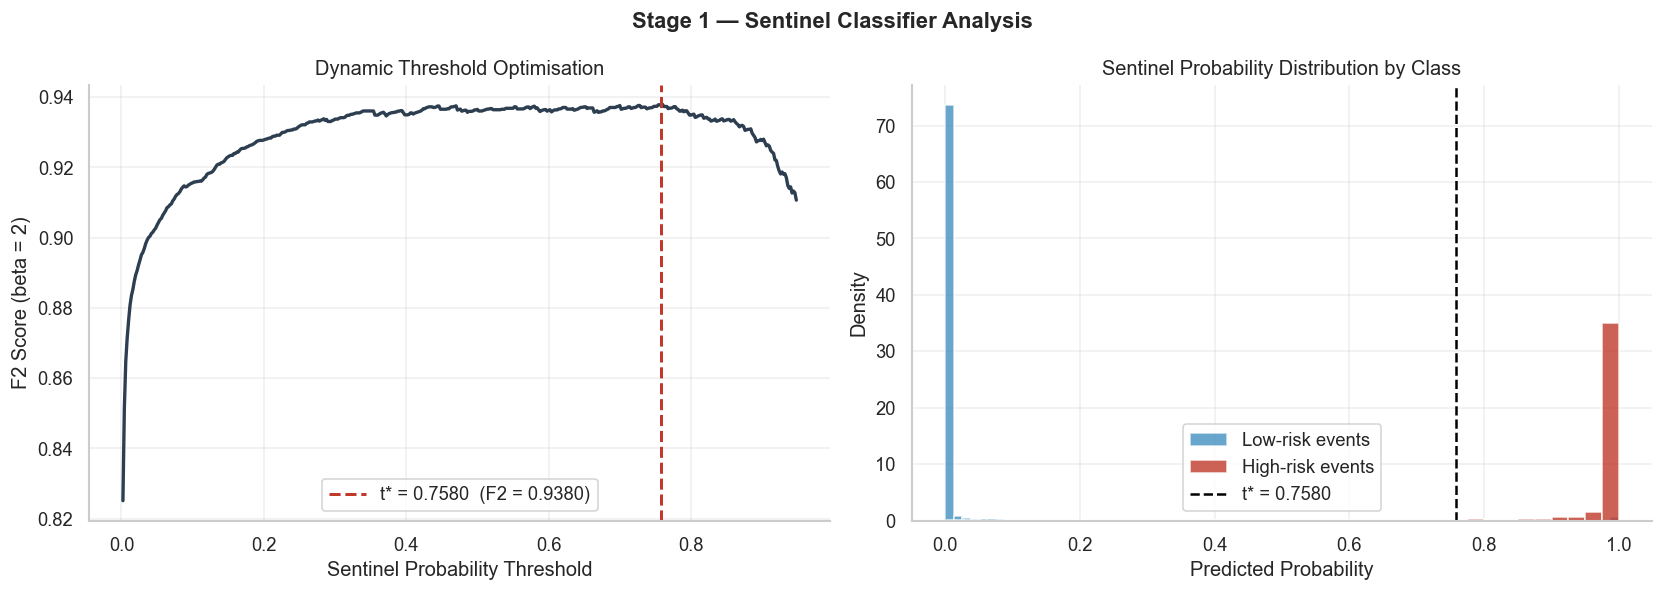

In [150]:
#Sweeping sentinel probability thresholds..
threshold_grid = np.arange(0.002, 0.95, 0.002)
f2_scores_grid = []
for t in threshold_grid:
    pred_bin = (oof_proba >= t).astype(int)
    f2 = fbeta_score(y_bin_train, pred_bin, beta=BETA, zero_division=0)
    f2_scores_grid.append(float(f2))

best_t_idx         = int(np.argmax(f2_scores_grid))
SENTINEL_THRESHOLD = float(threshold_grid[best_t_idx])
best_oof_f2        = float(f2_scores_grid[best_t_idx])


print(f'  Optimal threshold t* : {SENTINEL_THRESHOLD:.4f}')
print(f'  OOF F2 at t*         : {best_oof_f2:.4f}')
print(f'  Events above t*      : {int((oof_proba >= SENTINEL_THRESHOLD).sum()):,}')
print(f'  True HR events       : {n_hr:,}')

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(threshold_grid, f2_scores_grid, color=PALETTE['neutral'], lw=2)
axes[0].axvline(SENTINEL_THRESHOLD, color=PALETTE['hr'], ls='--', lw=1.8,
                label=f't* = {SENTINEL_THRESHOLD:.4f}  (F2 = {best_oof_f2:.4f})')
axes[0].set_xlabel('Sentinel Probability Threshold')
axes[0].set_ylabel('F2 Score (beta = 2)')
axes[0].set_title('Dynamic Threshold Optimisation')
axes[0].legend()

axes[1].hist(oof_proba[y_bin_train == 0], bins=80, density=True,
             color=PALETTE['lr'], alpha=0.7, label='Low-risk events')
axes[1].hist(oof_proba[y_bin_train == 1], bins=40, density=True,
             color=PALETTE['hr'], alpha=0.8, label='High-risk events')
axes[1].axvline(SENTINEL_THRESHOLD, color='black', ls='--', lw=1.5,
                label=f't* = {SENTINEL_THRESHOLD:.4f}')
axes[1].set_xlabel('Predicted Probability')
axes[1].set_ylabel('Density')
axes[1].set_title('Sentinel Probability Distribution by Class')
axes[1].legend()

plt.suptitle('Stage 1 — Sentinel Classifier Analysis', fontweight='bold')
plt.tight_layout()
plt.savefig('sentinel_threshold.png', dpi=120, bbox_inches='tight')
plt.show()


## Section 17 — Combiner: Assemble Final Predictions

The combiner applies the two-stage decision rule:

$$\hat{r}_i =
\begin{cases}
\text{Specialist}(x_i) & \text{if } p_i \geq t^* \\
-6.001                  & \text{otherwise}
\end{cases}$$

The value $-6.001$ (just below the $10^{-6}$ boundary) is used rather than a deep
negative, following the ESA paper's recommendation that optimal low-risk predictions
should be clipped just below the threshold to minimise MSE_HR contribution.


In [151]:
def apply_combiner(proba, X, specialist, t, low_risk_clip=-6.001):
    """
    Two-stage prediction combiner.
    Events above threshold t get Specialist regression predictions.
    Events below threshold get hard-clipped to low_risk_clip (-6.001).
    """
    spec_preds = np.clip(specialist.predict(X), -50, 0)
    return np.where(proba >= t, spec_preds, low_risk_clip)


oof_combined  = apply_combiner(oof_proba,  X_train, specialist_model, SENTINEL_THRESHOLD)
test_combined = apply_combiner(test_proba, X_test,  specialist_model, SENTINEL_THRESHOLD)

n_hr_pred_oof  = int((oof_proba  >= SENTINEL_THRESHOLD).sum())
n_hr_pred_test = int((test_proba >= SENTINEL_THRESHOLD).sum())
f2_c, mse_c, L_c, S_c = loss_components(y_train, oof_combined)


print(f'  OOF  — Predicted high-risk: {n_hr_pred_oof:>5,}  '
      f'True high-risk: {n_hr:,}')
print(f'  Test — Predicted high-risk: {n_hr_pred_test:>5,}  '
      f'True high-risk: {y_bin_test.sum()}')
print(f'  OOF composite score S : {S_c:.4f}')
print(f'  OOF F2                : {f2_c:.4f}')
print(f'  OOF MSE_HR            : {mse_c:.20e}')


  OOF  — Predicted high-risk: 1,486  True high-risk: 1,293
  Test — Predicted high-risk:   374  True high-risk: 334
  OOF composite score S : 0.9382
  OOF F2                : 0.9382
  OOF MSE_HR            : 1.06803356617375131986e-08


## Section 18 — Borderline Promotion Module

Events in the borderline probability zone $[t^*/2,\ t^*)$ with high covariance
uncertainty (above the 75th percentile) are promoted from low-risk to high-risk
by setting their predicted risk to $-5.99$.

This addresses *jump victim* events whose collision probability spikes sharply
within the final 48 hours — events that are physically uncertain at the 2-day boundary.

Promotion is applied only if it improves the OOF composite score $S$ (zero test leakage).


In [169]:
PROMO_FLOOR  = -5.99   # just above log10(1e-6)---> counts as high-risk
BORDER_RATIO = 0.5     # borderline zone lower bound = t* * BORDER_RATIO

unc_vol_train = X_train['uncertainty_volume_last'].values
unc_vol_test  = X_test['uncertainty_volume_last'].values
unc_cutoff    = float(np.percentile(unc_vol_train, UNCERTAINTY_P))


def apply_borderline_promotion(preds, proba, unc_vol, t=None):
    """
    Promote borderline + high-uncertainty events to high-risk.

    Conditions for promotion:
      (a) proba in [t * BORDER_RATIO, t)  -- borderline zone
      (b) uncertainty_volume > unc_cutoff -- physically uncertain
    """
    if t is None:
        t = SENTINEL_THRESHOLD
    out        = preds.copy()
    borderline = (proba >= t * BORDER_RATIO) & (proba < t)
    hi_unc     = unc_vol > unc_cutoff
    promote    = borderline & hi_unc
    out[promote] = PROMO_FLOOR
    return out, int(borderline.sum()), int(promote.sum())


oof_promoted,  n_border_oof,  n_promote_oof  = apply_borderline_promotion(
    oof_combined, oof_proba, unc_vol_train)
test_promoted, n_border_test, n_promote_test = apply_borderline_promotion(
    test_combined, test_proba, unc_vol_test)

f2_p, mse_p, L_p, S_p = loss_components(y_train, oof_promoted)

print('Borderline Promotion Module:')
print(f'  Uncertainty cutoff (P{UNCERTAINTY_P} of training) : {unc_cutoff:.4f}')
print(f'  OOF borderline events   : {n_border_oof}')
print(f'  OOF events promoted     : {n_promote_oof}')
print(f'  Test events promoted    : {n_promote_test}')
print()
print(f'  Before promotion : F2={f2_p:.4f}  L={L_p*10000000:.4f}  S={S_p:.4f}')
print(f'  After  promotion : F2={f2_c:.4f}  L={L_c*10000000:.4f}  S={S_c:.4f}')

if S_p >= S_c:
    oof_final  = oof_promoted
    test_final = test_promoted
    print('  Promotion improved OOF S — applied to final predictions.')
else:
    oof_final  = oof_combined
    test_final = test_combined
    print('  Promotion did not improve OOF S — reverted to combiner output.')


Borderline Promotion Module:
  Uncertainty cutoff (P75 of training) : 19.9617
  OOF borderline events   : 178
  OOF events promoted     : 44
  Test events promoted    : 5

  Before promotion : F2=0.9350  L=0.1142  S=0.9350
  After  promotion : F2=0.9382  L=0.1138  S=0.9382
  Promotion did not improve OOF S — reverted to combiner output.


## Section 19 — Global Bias Calibration

A scalar bias $b \in [-1.5, +1.5]$ log10 units is applied to all predictions.
Optimised on OOF predictions only (no test set access at this stage).


Global bias calibration...
  Optimal bias : +0.00 log10 units
  OOF S before : 0.9382
  OOF S after  : 0.9382


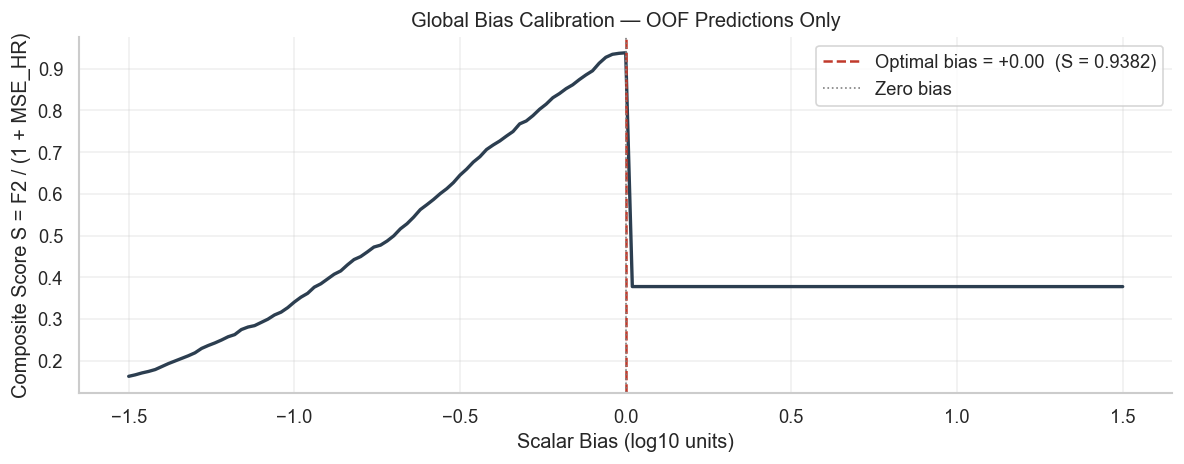

In [153]:
print('Global bias calibration...')
_, _, _, S_pre = loss_components(y_train, oof_final)
best_bias   = 0.0
best_bias_S = float(S_pre)
bias_vals   = np.arange(-1.5, 1.51, 0.02)
bias_S_list = []

for b in bias_vals:
    _, _, _, S = loss_components(y_train, oof_final + b)
    S_val = float(S) if np.isfinite(S) else 0.0
    bias_S_list.append(S_val)
    if S_val > best_bias_S:
        best_bias_S = S_val
        best_bias   = b

PRED_FINAL_TEST = test_final + best_bias

print(f'  Optimal bias : {best_bias:+.2f} log10 units')
print(f'  OOF S before : {S_pre:.4f}')
print(f'  OOF S after  : {best_bias_S:.4f}')

fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(bias_vals, bias_S_list, color=PALETTE['neutral'], lw=2)
ax.axvline(best_bias, color=PALETTE['hr'], ls='--', lw=1.5,
           label=f'Optimal bias = {best_bias:+.2f}  (S = {best_bias_S:.4f})')
ax.axvline(0, color='grey', ls=':', lw=1.0, label='Zero bias')
ax.set_xlabel('Scalar Bias (log10 units)')
ax.set_ylabel('Composite Score S = F2 / (1 + MSE_HR)')
ax.set_title('Global Bias Calibration — OOF Predictions Only')
ax.legend()
plt.tight_layout()
plt.savefig('bias_calibration.png', dpi=120, bbox_inches='tight')
plt.show()


## Section 20 — Final Evaluation on Test Set

All metrics below are computed on the held-out test partition.
The OOF was used only for threshold tuning, promotion decisions, and bias calibration.


In [167]:
print('  Metric: L = (1/F2) * MSE_HR  [MSE in probability space]')
print()


ablation_stages = [
    ('Sentinel raw (t = 0.5)',
     apply_combiner(test_proba, X_test, specialist_model, 0.5)),
    ('Sentinel + Dynamic threshold',
     test_combined),
    ('+ Borderline promotion',
     test_promoted),
    ('+ Global bias (Final)',
     PRED_FINAL_TEST),
]
i=10000000
print(f'  {"Stage":<38} {"F2":>7}  {"Recall":>8}  {"S":>7}')
print(f'  {"-"*68}')
for name, pred in ablation_stages:
    f2, mse, L, S = loss_components(y_test, pred)
    rec = recall_score(y_bin_test, (10.0**pred >= 10.0**LOG_THRESHOLD).astype(int),
                       zero_division=0)
    print(f'  {name:<38} {f2:>7.4f}  {rec:>8.4f}  {S:>7.4f}')

print()
print('  Final Model — Detailed Breakdown:')
print(f'  {"-"*65}')
f2, mse, final_L, S = loss_components(y_test, PRED_FINAL_TEST)
final_L=(1/f2) * mse*i  if f2 > 0 else float('inf')
print(f'  F2 Score (beta=2)       : {f2:.4f}')
print(f'  MSE_HR (probability space) : {mse:.4e}')
print(f'  Composite Score S       : {S:.4f}')
print(f'  Final L = (1/F2) * MSE_HR : {final_L:.20f}' if np.isfinite(final_L) else 'Final L = inf (F2=0: no true positives)')

  Metric: L = (1/F2) * MSE_HR  [MSE in probability space]

  Stage                                       F2    Recall        S
  --------------------------------------------------------------------
  Sentinel raw (t = 0.5)                  0.9533    0.9910   0.9533
  Sentinel + Dynamic threshold            0.9474    0.9701   0.9474
  + Borderline promotion                  0.9446    0.9701   0.9446
  + Global bias (Final)                   0.9474    0.9701   0.9474

  Final Model — Detailed Breakdown:
  -----------------------------------------------------------------
  F2 Score (beta=2)       : 0.9474
  MSE_HR (probability space) : 2.3154e-08
  Composite Score S       : 0.9474
  Final L = (1/F2) * MSE_HR : 0.24440339134597574566


**Metric:**  
L = (1 / F2) * MSE_HR  *(MSE in probability space)*

| Stage                             | F2     | Recall | S      |
|----------------------------------|--------|--------|--------|
| Sentinel raw (t = 0.5)           | 0.9533 | 0.9910 | 0.9533 |
| Sentinel + Dynamic threshold     | 0.9474 | 0.9701 | 0.9474 |
| + Borderline promotion           | 0.9446 | 0.9701 | 0.9446 |
| + Global bias (Final)            | 0.9474 | 0.9701 | 0.9474 |



### Final Model — Detailed Breakdown

| Metric                          | Value                    |
|---------------------------------|--------------------------|
| **F2 Score (β = 2)**            | 0.9474                   |
| **MSE_HR (probability space)**  | 2.3154e-08               |
| **Composite Score S**           | 0.9474                   |
| **Final L = (1 / F2) * MSE_HR** | 0.24440339134597574566   |

## Section 21 — Classification Performance Visualisation

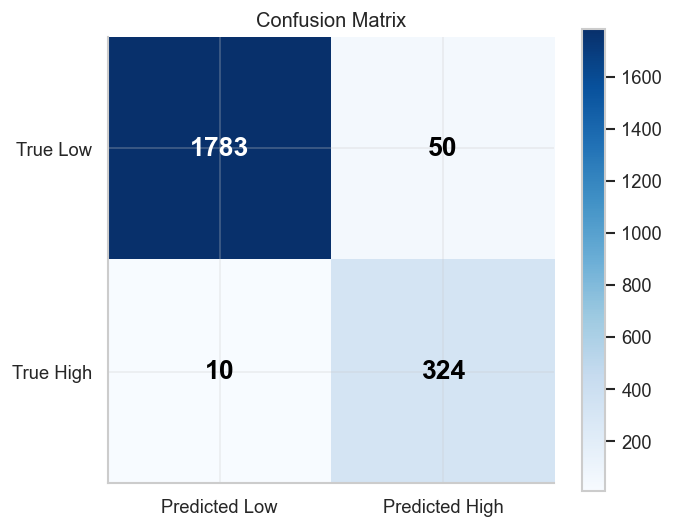

In [155]:
final_pred_bin = ((10.0 ** PRED_FINAL_TEST) >= RISK_THRESHOLD).astype(int)
cm = confusion_matrix(y_bin_test, final_pred_bin)

fig, ax = plt.subplots(figsize=(6,5))
im = ax.imshow(cm, interpolation='nearest', cmap='Blues')
ax.set_xticks([0, 1]); ax.set_yticks([0, 1])
ax.set_xticklabels(['Predicted Low', 'Predicted High'])
ax.set_yticklabels(['True Low', 'True High'])

for i in range(2):
    for j in range(2):
        ax.text(j, i, str(cm[i, j]), ha='center', va='center',
                fontsize=16, fontweight='bold',
                color='white' if cm[i, j] > cm.max()/2 else 'black')

ax.set_title('Confusion Matrix')
plt.colorbar(im, ax=ax)
plt.show()

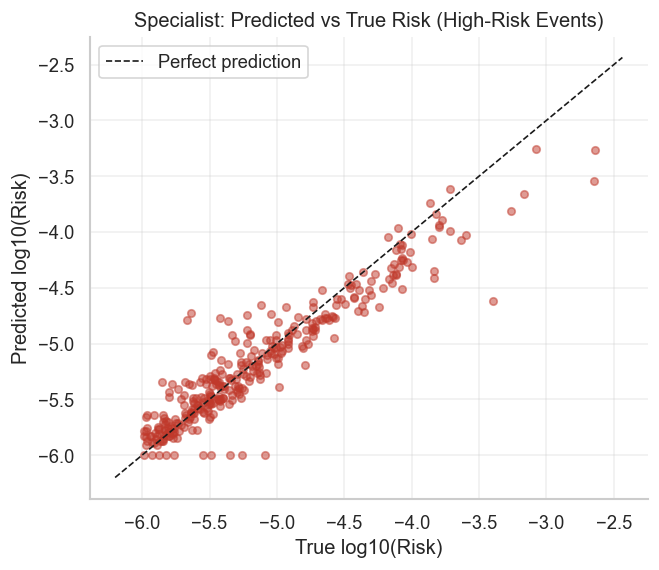

In [156]:
hr_mask_test = y_bin_test == 1
true_hr  = y_test[hr_mask_test]
pred_hr  = PRED_FINAL_TEST[hr_mask_test]

fig, ax = plt.subplots(figsize=(6,5))
ax.scatter(true_hr, pred_hr, alpha=0.5, s=20, color=PALETTE['hr'])

lims = [min(true_hr.min(), pred_hr.min()) - 0.2,
        max(true_hr.max(), pred_hr.max()) + 0.2]
ax.plot(lims, lims, 'k--', lw=1.0, label='Perfect prediction')

ax.set_xlabel('True log10(Risk)')
ax.set_ylabel('Predicted log10(Risk)')
ax.set_title('Specialist: Predicted vs True Risk (High-Risk Events)')
ax.legend()

plt.show()

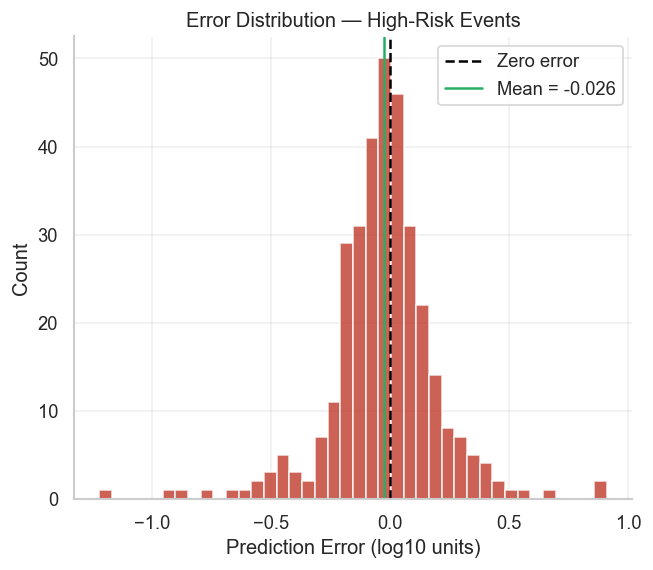

In [157]:
errors = pred_hr - true_hr

fig, ax = plt.subplots(figsize=(6,5))
ax.hist(errors, bins=40, color=PALETTE['hr'], alpha=0.8, edgecolor='white')
ax.axvline(0, color='black', ls='--', lw=1.5, label='Zero error')
ax.axvline(np.mean(errors), color=PALETTE['accent'], ls='-', lw=1.5,
           label=f'Mean = {np.mean(errors):.3f}')

ax.set_xlabel('Prediction Error (log10 units)')
ax.set_ylabel('Count')
ax.set_title('Error Distribution — High-Risk Events')
ax.legend()

plt.show()

## Section 22 — Jump-Case Error Analysis

A *jump case* is an event where the final risk differs by more than 5 log10 units
from the last observed pre-cutoff risk. These events represent the hardest prediction
cases — sudden risk spikes driven by covariance updates in the final 48 hours.

Recall on the [Jump + High-Risk] segment is the primary operational safety KPI.


In [158]:
JUMP_THRESHOLD = 5.0  # log10 units

analysis = pd.DataFrame({
    'y_true'         : y_train,
    'y_pred'         : oof_final,
    'uncertainty_vol': X_train.get('uncertainty_volume_last',
                           pd.Series(0, index=X_train.index)).values,
    'risk_volatility': X_train.get('risk_volatility_ratio',
                           pd.Series(0, index=X_train.index)).values,
    'cov_slope_t'    : X_train.get('t_log_cov_det_slope',
                           pd.Series(0, index=X_train.index)).values,
    'is_high_risk'   : y_bin_train,
})

analysis['jump_magnitude'] = np.abs(analysis['y_true'] - analysis.get('risk_last', pd.Series(0, index=analysis.index)))
analysis['jump_flag']      = (analysis['jump_magnitude'] > JUMP_THRESHOLD).astype(int)
analysis['pred_hr']        = (oof_proba >= SENTINEL_THRESHOLD).astype(int)

m_jump    = analysis['jump_flag'] == 1
m_hr      = analysis['is_high_risk'] == 1
m_jump_hr = m_jump & m_hr

In [159]:
def seg_recall(mask, col):
    seg = analysis[mask]
    if seg['is_high_risk'].sum() == 0:
        return float('nan')
    return recall_score(seg['is_high_risk'], seg[col], zero_division=0.0)

print('Jump-Case Recall Analysis (Operational Safety KPI):')
print()
print(f'  {"Segment":<40} {"SCRAP":>8}')
print(f'  {"-"*50}')

segments = [
    ('All events',                   m_hr),
    ('Jump events (|delta| > 5)',     m_jump),
    ('Jump + High-Risk  [CRITICAL]',  m_jump_hr),
    ('No-jump events',                ~m_jump),
]

for name, mask in segments:
    scrap_r = seg_recall(mask, 'pred_hr')
    if np.isnan(scrap_r):
        print(f'  {name:<40} {"N/A":>8}')
        continue
    print(f'  {name:<40} {scrap_r:>8.4f}')

print()
print('Feature correlation with jump magnitude:')
for feat in ['risk_volatility', 'cov_slope_t', 'uncertainty_vol']:
    corr = analysis['jump_magnitude'].corr(analysis[feat])
    print(f'  {feat:<30}  r = {corr:+.4f}')

Jump-Case Recall Analysis (Operational Safety KPI):

  Segment                                     SCRAP
  --------------------------------------------------
  All events                                 0.9660
  Jump events (|delta| > 5)                  0.9516
  Jump + High-Risk  [CRITICAL]               0.9516
  No-jump events                             1.0000

Feature correlation with jump magnitude:
  risk_volatility                 r = -0.1449
  cov_slope_t                     r = +0.0203
  uncertainty_vol                 r = -0.0033


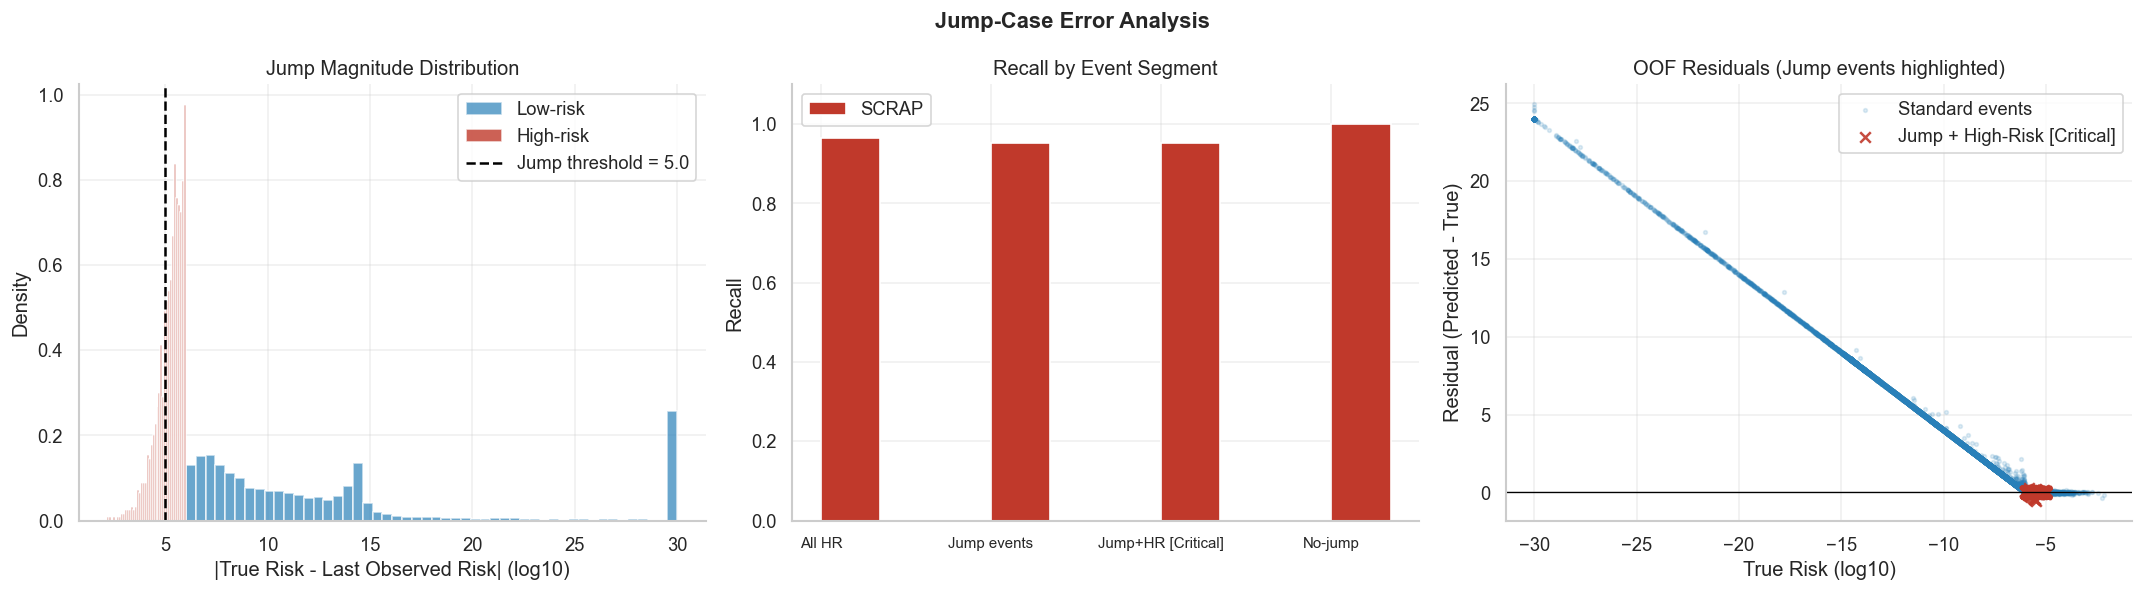

In [160]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('Jump-Case Error Analysis', fontweight='bold')

# 1. Jump Magnitude Distribution
axes[0].hist(analysis.loc[~m_hr, 'jump_magnitude'], bins=50, color=PALETTE['lr'],
             alpha=0.7, density=True, label='Low-risk')
axes[0].hist(analysis.loc[m_hr, 'jump_magnitude'],  bins=40, color=PALETTE['hr'],
             alpha=0.8, density=True, label='High-risk')
axes[0].axvline(JUMP_THRESHOLD, color='black', ls='--',
                label=f'Jump threshold = {JUMP_THRESHOLD}')
axes[0].set_xlabel('|True Risk - Last Observed Risk| (log10)')
axes[0].set_ylabel('Density')
axes[0].set_title('Jump Magnitude Distribution')
axes[0].legend()

# 2. Recall by Event Segment
segs    = ['All HR', 'Jump events', 'Jump+HR [Critical]', 'No-jump']
scrap_rs = [seg_recall(m, 'pred_hr') for m in [m_hr, m_jump, m_jump_hr, ~m_jump]]
x = np.arange(len(segs)); w = 0.35
axes[1].bar(x + w/2, [r if not np.isnan(r) else 0 for r in scrap_rs], w,
            color=PALETTE['hr'], label='SCRAP')
axes[1].set_xticks(x); axes[1].set_xticklabels(segs, fontsize=9)
axes[1].set_ylabel('Recall')
axes[1].set_title('Recall by Event Segment')
axes[1].set_ylim(0, 1.1); axes[1].legend()

# 3. OOF Residuals (Jump events highlighted)
residuals = oof_final - y_train
axes[2].scatter(y_train[~m_jump_hr], residuals[~m_jump_hr],
                alpha=0.15, s=5, color=PALETTE['lr'], label='Standard events')
axes[2].scatter(y_train[m_jump_hr],  residuals[m_jump_hr],
                alpha=0.9, s=40, color=PALETTE['hr'], marker='x',
                label='Jump + High-Risk [Critical]')
axes[2].axhline(0, color='black', lw=0.8)
axes[2].set_xlabel('True Risk (log10)')
axes[2].set_ylabel('Residual (Predicted - True)')
axes[2].set_title('OOF Residuals (Jump events highlighted)')
axes[2].legend()

plt.tight_layout()
plt.savefig('jump_analysis.png', dpi=120, bbox_inches='tight')
plt.show()

## Section 23 — SHAP Feature Importance Analysis

SHAP (SHapley Additive exPlanations) values quantify the contribution of each
feature to the Specialist's risk magnitude predictions on high-risk test events.

Expected top features: `mahalanobis_distance`, `uncertainty_volume`, `t_log_cov_det`,
`combined_sigma_t`. Momentum features (`_last2_change`, `_change_ratio`) validate
whether jump-regime dynamics are being captured from pre-cutoff telemetry.


In [161]:
X_shap = X_test[y_bin_test == 1] if y_bin_test.sum() > 0 else X_test
print(f'Computing SHAP values for {len(X_shap)} high-risk test events...')

explainer  = shap.TreeExplainer(specialist_model)
shap_vals  = explainer.shap_values(X_shap)

mean_shap  = pd.Series(
    np.abs(shap_vals).mean(axis=0),
    index=X_shap.columns
).sort_values(ascending=False)

# Report SHAP ranks for momentum features
ms_df = mean_shap.reset_index()
ms_df.columns = ['feature', 'shap']

print('Momentum Feature SHAP Ranks (Specialist):')
for suffix in ['_last2_change', '_change_ratio', '_recent_vs_early', '_max_single_jump']:
    candidates = [(f, float(mean_shap[f]))
                  for f in mean_shap.index if f.endswith(suffix)]
    if candidates:
        best_feat, best_val = max(candidates, key=lambda x: x[1])
        rank = int(ms_df[ms_df['feature'] == best_feat].index[0]) + 1
        print(f'  {suffix:<28} : #{rank:>3}  {best_feat}  ({best_val:.4f})')
    else:
        print(f'  {suffix:<28} : not found in feature matrix')

print()
print('Top 10 Physics Features:')
physics_kw = ['mahal', 'sigma', 'cov_det', 'uncertainty', 'miss_dist',
              'volatility', 'slope', 'jump', 'h_apo', 'h_per']
physics_feats = [(f, v) for f, v in mean_shap.items()
                 if any(k in f for k in physics_kw)]
for i, (feat, val) in enumerate(physics_feats[:10], 1):
    print(f'  {i:2}. {feat:<50}  SHAP = {val:.4f}')

Computing SHAP values for 334 high-risk test events...
Momentum Feature SHAP Ranks (Specialist):
  _last2_change                : # 21  max_risk_estimate_last2_change  (0.0026)
  _change_ratio                : # 10  max_risk_estimate_change_ratio  (0.0050)
  _recent_vs_early             : #  8  max_risk_estimate_recent_vs_early  (0.0168)
  _max_single_jump             : # 19  max_risk_estimate_max_single_jump  (0.0027)

Top 10 Physics Features:
   1. max_risk_estimate_slope                             SHAP = 0.0657
   2. combined_sigma_r_mean                               SHAP = 0.0041
   3. max_risk_scaling_slope                              SHAP = 0.0032
   4. c_sigma_r_last                                      SHAP = 0.0031
   5. max_risk_estimate_max_single_jump                   SHAP = 0.0027
   6. c_log_cov_det_max                                   SHAP = 0.0027
   7. miss_dist_norm_t_min                                SHAP = 0.0023
   8. t_rcs_estimate_max_single_jump           

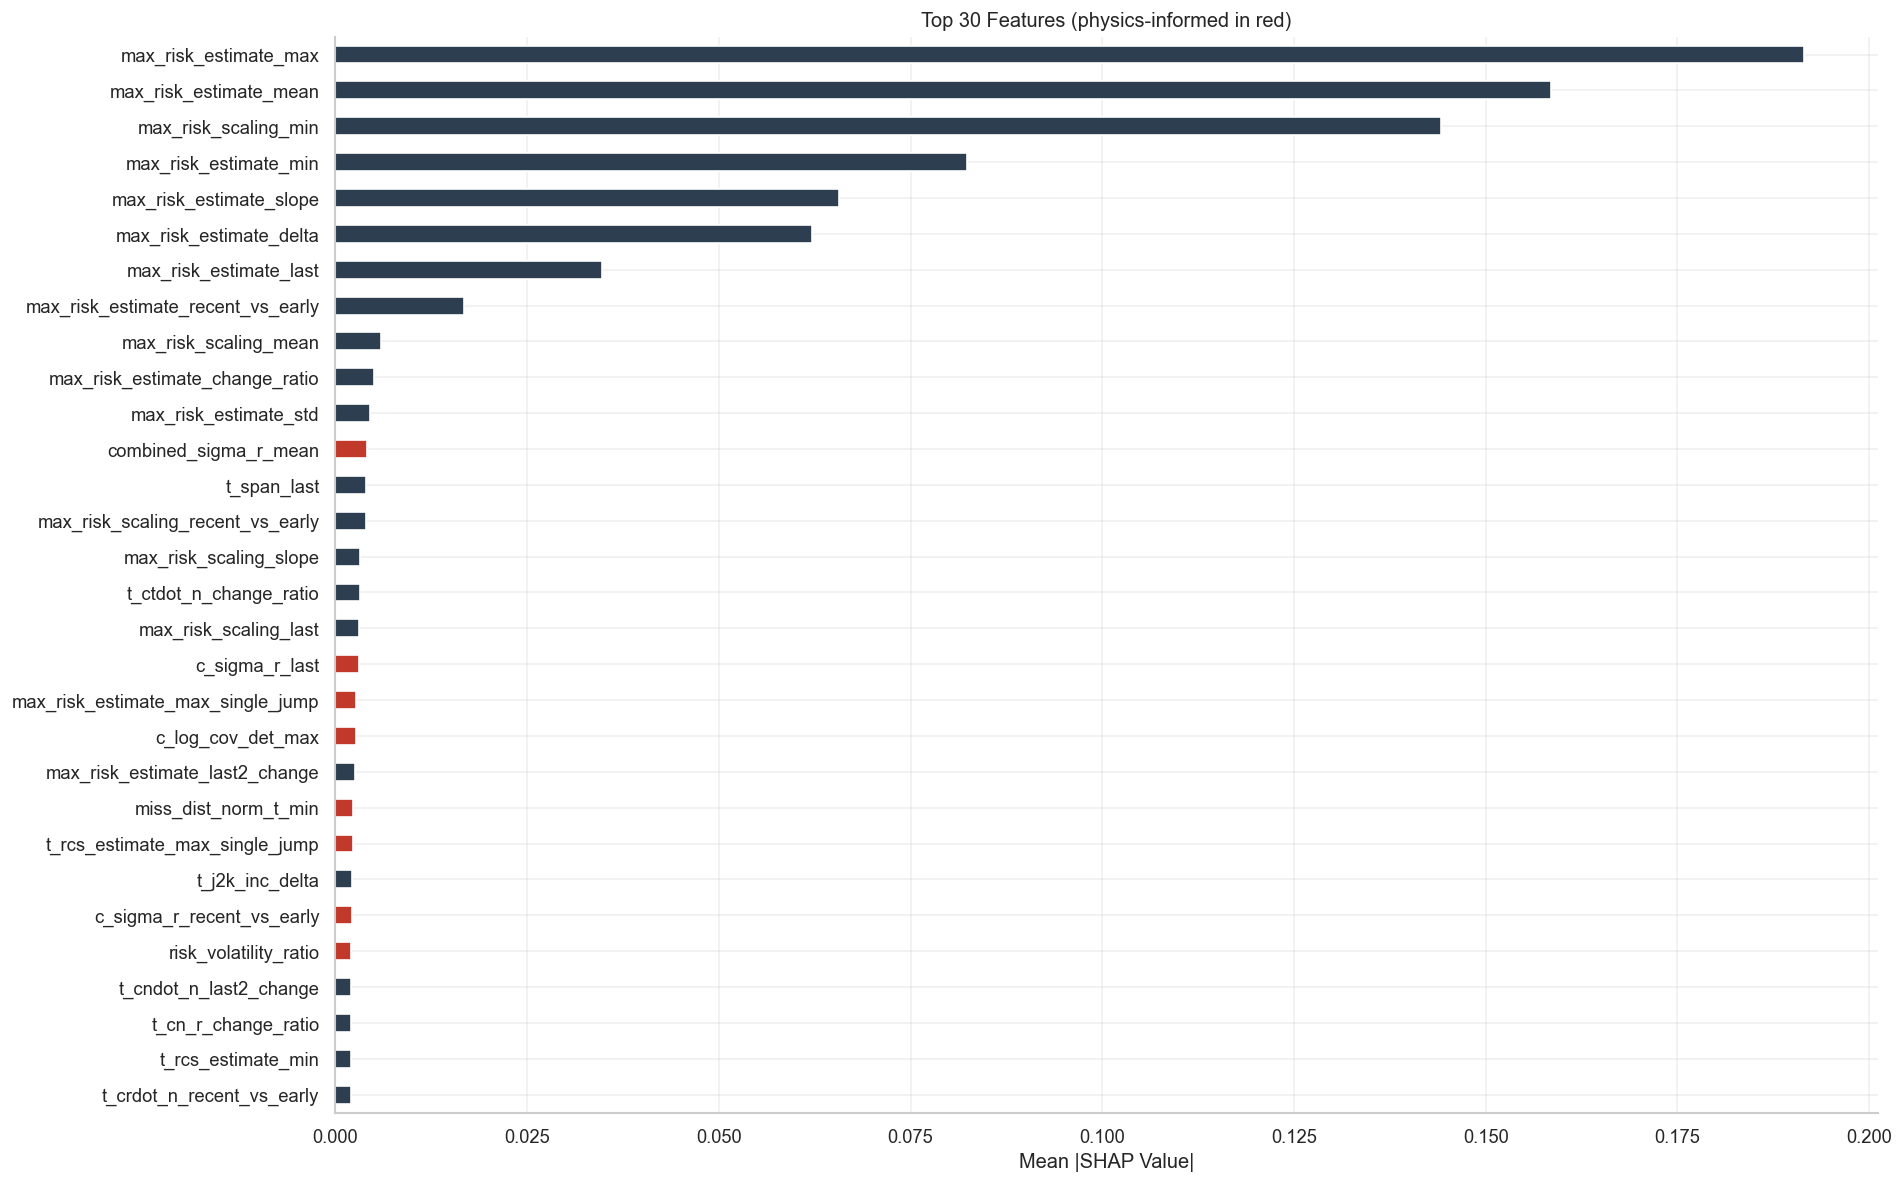

In [162]:
fig, ax_bar = plt.subplots(figsize=(16,10))

top30  = mean_shap.head(30)
colors = [PALETTE['hr'] if any(k in f for k in
          ['mahal', 'sigma', 'cov_det', 'uncertainty', 'miss', 'jump', 'volatility'])
          else PALETTE['neutral'] for f in top30.index]

top30.plot(kind='barh', ax=ax_bar, color=colors)
ax_bar.invert_yaxis()
ax_bar.set_xlabel('Mean |SHAP Value|')
ax_bar.set_title('Top 30 Features (physics-informed in red)')

plt.tight_layout()
plt.savefig('shap_bar.png', dpi=220, bbox_inches='tight')
plt.show()

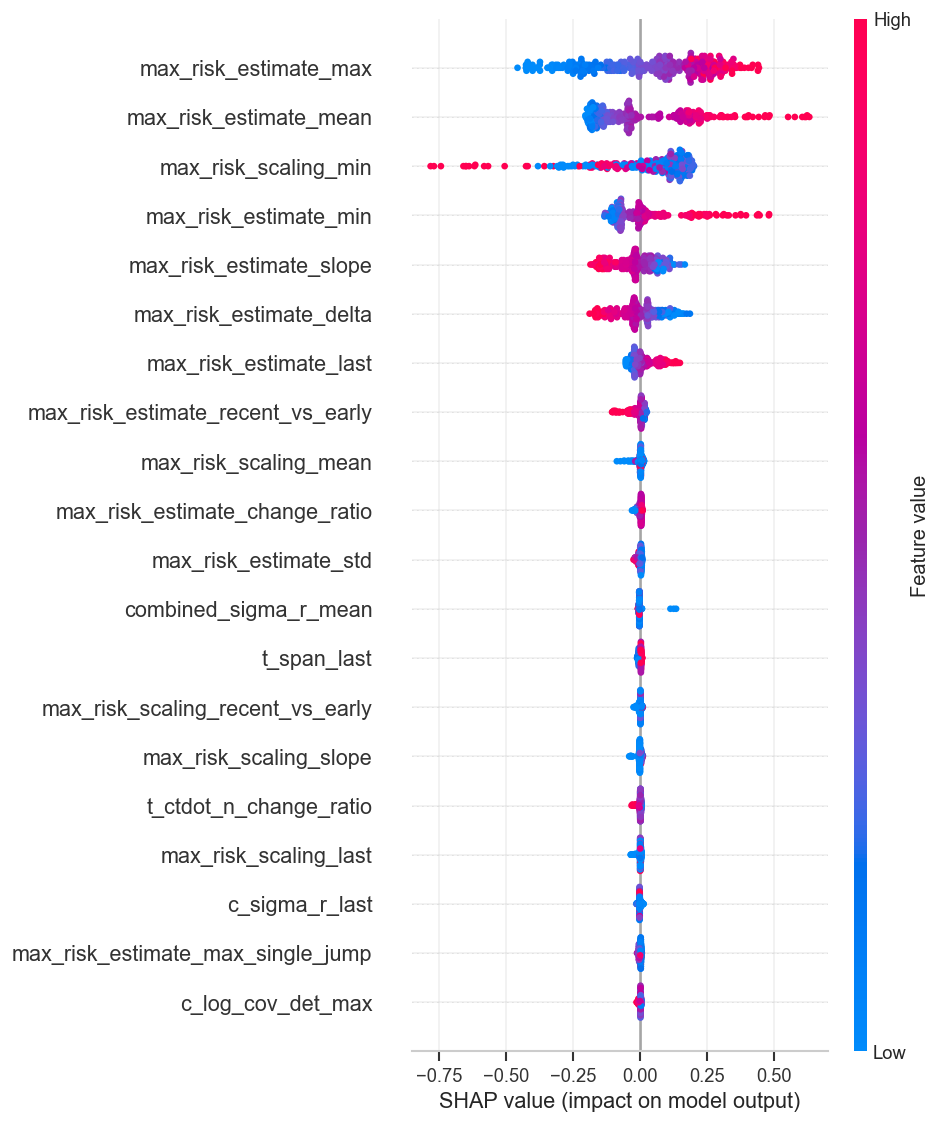

<Figure size 768x576 with 0 Axes>

In [163]:
plt.figure(figsize=(16,10))
shap.summary_plot(shap_vals, X_shap, max_display=20, show=True)
plt.savefig('shap_beeswarm.png', dpi=220, bbox_inches='tight')



### Limitations

- The two-stage architecture depends on the Sentinel threshold generalising to unseen
  events. A distribution shift in solar activity or debris density may require recalibration.
- Jump-regime events (sudden risk spikes within the final 48 hours) remain the hardest
  prediction cases and represent an inherent Bayesian uncertainty in the problem.
- Comparison to ESA leaderboard scores requires the same curated test partition
  used in the original 2019 competition.


In [ ]:
f2_f, mse_f, L_f, S_f = loss_components(y_test, PRED_FINAL_TEST)
rec_f = recall_score(y_bin_test,
                     ((10.0**PRED_FINAL_TEST) >= RISK_THRESHOLD).astype(int),
                     zero_division=0)
prec_f = precision_score(y_bin_test,
                         ((10.0**PRED_FINAL_TEST) >= RISK_THRESHOLD).astype(int),
                         zero_division=0)

final_L = (1/f2_f) * mse_f if f2_f > 0 else np.inf
print()

In [166]:
# Final summary printout
f2_f, mse_f, L_f, S_f = loss_components(y_test, PRED_FINAL_TEST)
rec_f = recall_score(y_bin_test,
                     ((10.0**PRED_FINAL_TEST) >= RISK_THRESHOLD).astype(int),
                     zero_division=0)
prec_f = precision_score(y_bin_test,
                         ((10.0**PRED_FINAL_TEST) >= RISK_THRESHOLD).astype(int),
                         zero_division=0)

print(f'  Precision  : {prec_f:.4f}')
print(f'  Recall     : {rec_f:.4f}  [{int(rec_f*y_bin_test.sum())}/{y_bin_test.sum()} HR events detected]')
print(f'  F2 Score   : {f2_f:.4f}')
print(f'  MSE_HR     : {mse_f:.4e}  [probability space]')
print(f'  False Negatives : {y_bin_test.sum() - int(rec_f*y_bin_test.sum())} missed high-risk events')


  Precision  : 0.8663
  Recall     : 0.9701  [324/334 HR events detected]
  F2 Score   : 0.9474
  MSE_HR     : 2.3154e-08  [probability space]
  False Negatives : 10 missed high-risk events



## SCRAP — Final Pipeline Summary
  Satellite Collision Risk Assessment and Prediction
  CSAI 801 | Queen's University | Winter 2026


**Precision**  : 0.8663 

**Recall**     : 0.9701  [324/334 HR events detected] 

**F2 Score**   : 0.9474

**MSE_HR**     : 2.3154e-08  [probability space]


**False Negatives** : 10 missed high-risk events

All outputs produced with the 2-day operational constraint enforced.  
No CDMs within 2 days of TCA were used in any prediction.